# ST-GCN: Обучение классификатора жестов РЖЯ (Slovo, 1000 классов)

**Google Colab Pro** | GPU: A100 / H100 | Время: ~8–12 ч

## Что делает этот ноутбук
1. Загружает предобработанный датасет Slovo RSL из Google Drive (numpy-массивы)

2. Определяет и обучает ST-GCN (Spatial-Temporal Graph Convolutional Network)
на 75 ключевых точках DWPose (33 поза + 21 левая рука + 21 правая рука)

3. Использует улучшенную архитектуру:

 - Focal Loss для борьбы с дисбалансом классов

- Temporal Attention для фокусировки на ключевых моментах жеста

- Комбинированный пулинг (Avg + Max) для сохранения пространственной информации

- Усиленная аугментация (jitter σ=0.05, temporal warp, hand rotation и др.)

- Динамическое уменьшение learning rate (ReduceLROnPlateau)

4. Логирует метрики в MLflow на DAGsHub (https://dagshub.com/noviyblock/glossa)

5. Экспортирует ONNX-модель в формате (B, T, 75, 3) → (B, 1000)

6. Пушит модель через DVC

## Перед запуском
Добавьте в **Colab → Secrets (🔑)**:
- `DAGSHUB_TOKEN` — токен DAGsHub (Settings → Access Tokens)
- `MLFLOW_TRACKING_USERNAME` — ваш логин DAGsHub (`noviyblock`)
- `MLFLOW_TRACKING_PASSWORD` — тот же токен DAGsHub

Датасет должен быть в Drive по пути `/content/drive/MyDrive/glossa/data/`:
```
data/gestures/processed/train/features.npy  # (N, 32, 75, 3)
data/gestures/processed/train/labels.npy
data/gestures/processed/val/features.npy
data/gestures/processed/val/labels.npy
data/gestures/processed/class_names.json
```

# Ячейка 1 — Монтирование Google Drive и установка зависимостей

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive смонтирован')

# Установка зависимостей
!pip install -q dagshub mlflow pyyaml onnx onnxruntime
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q scikit-learn matplotlib pandas

print('✅ Все зависимости успешно установлены')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive смонтирован
✅ Все зависимости успешно установлены


# Ячейка 2 — Настройка DAGsHub и Google Drive

In [2]:
import os
import time
import random
import json
import shutil
from pathlib import Path

# Пути для сохранения моделей
DRIVE_ROOT  = '/content/drive/MyDrive/glossa'
MODELS_DIR  = f'{DRIVE_ROOT}/models'
DATA_DIR    = f'{DRIVE_ROOT}/data/gestures/processed'
PLOTS_DIR   = f'{MODELS_DIR}/plots'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Загружаем секреты из Colab
from google.colab import userdata
for key in ('DAGSHUB_TOKEN', 'MLFLOW_TRACKING_USERNAME', 'MLFLOW_TRACKING_PASSWORD'):
    try:
        os.environ[key] = userdata.get(key)
    except Exception:
        print(f'[Предупреждение] Секрет {key} не найден')

# Настраиваем S3-совместимое хранилище DAGsHub
token = os.environ.get('DAGSHUB_TOKEN') or os.environ.get('MLFLOW_TRACKING_PASSWORD', '')
if token:
    os.environ.setdefault('AWS_ACCESS_KEY_ID',     token)
    os.environ.setdefault('AWS_SECRET_ACCESS_KEY', token)
    os.environ.setdefault('MLFLOW_S3_ENDPOINT_URL', 'https://dagshub.com/noviyblock/glossa.s3')

# Инициализируем DAGsHub → MLflow
try:
    import dagshub
    dagshub.init(repo_owner='noviyblock', repo_name='glossa', mlflow=True)
    print('[DAGsHub] Инициализация успешна')
    print('[DAGsHub] UI: https://dagshub.com/noviyblock/glossa')
except Exception as e:
    import mlflow
    mlflow.set_tracking_uri('https://dagshub.com/noviyblock/glossa.mlflow')
    print(f'[MLflow] Fallback режим: {e}')

Accessing as noviyblock

Initialized MLflow to track repo "noviyblock/glossa"

Repository noviyblock/glossa initialized!

[DAGsHub] Инициализация успешна
[DAGsHub] UI: https://dagshub.com/noviyblock/glossa


# Ячейка 3 — Конфигурация

In [3]:
import torch
import numpy as np

CFG = {
    # Данные
    'num_classes':      1000,   # жесты РЖЯ из датасета Slovo (количество классов)
    'sequence_length':  32,     # TARGET_FRAMES из preprocessing
    'num_nodes':        75,     # 33 поза + 21 левая рука + 21 правая рука

    # Архитектура
    'mobile_mode':      False,  # True → 1 партиция (быстрее на Poco M5)
                                # False → 3 партиции (лучше качество)
    'use_temporal_attention': True,  # Включаем Temporal Attention

    # Обучение
    'batch_size':       32,
    'epochs':           200,    # Увеличено с 100 до 200
    'lr':               1e-3,
    'weight_decay':     1e-4,
    'patience':         25,     # Увеличено с 10 до 25
    'flip_prob':        0.5,    # аугментация: горизонтальное отражение
    'seed':             42,
    'label_smoothing':  0.1,    # для Focal Loss не используется

    # Focal Loss параметры
    'focal_alpha':      0.25,
    'focal_gamma':      2.0,

    # Экспорт
    'opset_version':    18,

    # MLflow
    'experiment_name':  '01_glossa_stgcn_train',
    'run_name':         f'stgcn_train_{time.strftime("%Y%m%d_%H%M")}',
}

# Воспроизводимость
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'mobile_mode: {CFG["mobile_mode"]} → партиций GCN: {1 if CFG["mobile_mode"] else 3}')
print(f'temporal_attention: {CFG["use_temporal_attention"]}')

Устройство: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB
mobile_mode: False → партиций GCN: 3
temporal_attention: True


# Ячейка 4 —  ГРАФ СКЕЛЕТА ДЛЯ DWPOSE (COCO-WholeBody)

In [11]:
import numpy as np
import torch
from scipy.sparse.csgraph import connected_components

# ОБЪЯВЛЯЕМ ГЛОБАЛЬНЫЕ ПЕРЕМЕННЫЕ
A_np = None
A_partition_np = None
skeleton_graph = None

def load_skeleton_graph():
    """
    Граф скелета для DWPose (COCO-WholeBody) → 75 точек.

    Структура:
    - 0-32: 33 точки позы (17 COCO body + 6 feet + 10 extra)
    - 33-53: 21 точка левой руки (COCO 91-111)
    - 54-74: 21 точка правой руки (COCO 112-132)
    """
    global A_np, A_partition_np, skeleton_graph

    # ================================================================
    # 1. ОПРЕДЕЛЕНИЕ СВЯЗЕЙ
    # ================================================================

    # COCO body connections (0-16)
    COCO_EDGES = [
        (0, 1), (0, 2), (1, 3), (2, 4),           # нос → глаза/уши
        (5, 6), (5, 7), (6, 8), (7, 9),           # плечи → локти → запястья
        (5, 11), (6, 12), (11, 12),               # плечи → бедра
        (11, 13), (13, 15), (15, 17), (17, 19),   # левая нога
        (12, 14), (14, 16), (16, 18), (18, 20),   # правая нога
        (0, 5), (0, 6),                           # нос → плечи
        (5, 7), (7, 9),                           # левая рука
        (6, 8), (8, 10),                          # правая рука
    ]

    # Feet connections (17-22)
    FEET_EDGES = [
        (17, 19), (19, 21),  # левая стопа
        (18, 20), (20, 22),  # правая стопа
        (17, 18),            # связь между ногами
    ]

    # Extra body connections (23-32) - дублируем ключевые суставы
    EXTRA_EDGES = [
        (23, 5), (24, 6),    # плечи
        (25, 11), (26, 12),  # бедра
        (27, 13), (28, 14),  # колени
        (29, 15), (30, 16),  # лодыжки
        (31, 5), (32, 6),    # дубли плеч
    ]

    # Hand connections (0-20) для левой и правой руки
    HAND_EDGES = [
        (0, 1), (0, 5), (0, 9), (0, 13), (0, 17),
        (1, 2), (2, 3),  (3, 4),
        (5, 6), (6, 7),  (7, 8),
        (9, 10), (10, 11), (11, 12),
        (13, 14), (14, 15), (15, 16),
        (17, 18), (18, 19), (19, 20),
    ]

    # ================================================================
    # 2. СБОРКА ВСЕХ РЁБЕР
    # ================================================================
    edges = set()

    # Поза (0-32)
    for i, j in COCO_EDGES:
        if i < 17 and j < 17:
            edges.add((i, j))
            edges.add((j, i))

    for i, j in FEET_EDGES:
        if 17 <= i <= 22 and 17 <= j <= 22:
            edges.add((i, j))
            edges.add((j, i))

    for i, j in EXTRA_EDGES:
        edges.add((i, j))
        edges.add((j, i))

    # Левая рука (33-53)
    for i, j in HAND_EDGES:
        edges.add((33 + i, 33 + j))
        edges.add((33 + j, 33 + i))

    # Правая рука (54-74)
    for i, j in HAND_EDGES:
        edges.add((54 + i, 54 + j))
        edges.add((54 + j, 54 + i))

    # ================================================================
    # 3. СВЯЗЬ: ПОЗА → РУКИ
    # ================================================================
    # COCO: 4 = правое запястье, 7 = левое запястье
    edges.add((7, 33)); edges.add((33, 7))   # левое запястье → левая рука
    edges.add((4, 54)); edges.add((54, 4))   # правое запястье → правая рука

    # Дополнительные связи для надежности
    edges.add((5, 33)); edges.add((33, 5))   # левое плечо → левая рука
    edges.add((6, 54)); edges.add((54, 6))   # правое плечо → правая рука

    # ================================================================
    # 4. СВЯЗЬ: ЛИЦО (узлы 1, 2, 3, 8, 9, 10) → НОС (узел 0)
    # ================================================================
    # COCO: 1=правый глаз, 2=левый глаз, 3=правый нос, 8=левый нос
    #       9=правое ухо, 10=левое ухо
    face_nodes = [1, 2, 3, 8, 9, 10]
    for node in face_nodes:
        edges.add((node, 0)); edges.add((0, node))
    print('  🔗 Связаны узлы лица с носом (узел 0)')

    # ================================================================
    # 5. СВЯЗЬ: FEET (17-22) → ТЕЛО
    # ================================================================
    # Связываем стопы с телом через лодыжки
    edges.add((15, 17)); edges.add((17, 15))  # левая лодыжка → левая стопа
    edges.add((16, 18)); edges.add((18, 16))  # правая лодыжка → правая стопа

    # ================================================================
    # 6. ПОСТРОЕНИЕ МАТРИЦЫ СМЕЖНОСТИ
    # ================================================================
    V = 75
    A = np.zeros((V, V), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1.0
        A[j, i] = 1.0

    # Self-loops
    np.fill_diagonal(A, 1.0)

    # ================================================================
    # 7. ПРОВЕРКА И ИСПРАВЛЕНИЕ ИЗОЛИРОВАННЫХ УЗЛОВ
    # ================================================================
    isolated = np.where((A > 0).sum(axis=1) - 1 == 0)[0]
    if len(isolated) > 0:
        print(f'  ⚠️ Найдены изолированные узлы: {isolated.tolist()}')
        for node in isolated:
            if node < 33:
                # Поза: связываем с носом (узел 0)
                A[node, 0] = 1.0
                A[0, node] = 1.0
            elif node < 54:
                # Левая рука: связываем с основанием кисти (узел 33)
                A[node, 33] = 1.0
                A[33, node] = 1.0
            else:
                # Правая рука: связываем с основанием кисти (узел 54)
                A[node, 54] = 1.0
                A[54, node] = 1.0
        print(f'  🔗 Исправлено {len(isolated)} изолированных узлов')

    # ================================================================
    # 8. ПРОВЕРКА СВЯЗНОСТИ
    # ================================================================
    n_components, labels = connected_components(A, directed=False)
    print(f'  Компонент связности: {n_components}')

    if n_components > 1:
        print(f'  ⚠️ Граф НЕ связный! Добавляем межкомпонентные связи...')
        comp_nodes = [np.where(labels == comp)[0] for comp in range(n_components)]
        for i in range(1, n_components):
            a = comp_nodes[0][0]
            b = comp_nodes[i][0]
            A[a, b] = 1.0
            A[b, a] = 1.0
        n_components, labels = connected_components(A, directed=False)
        print(f'  Компонент связности после исправления: {n_components}')

    # ================================================================
    # 9. НОРМАЛИЗАЦИЯ МАТРИЦЫ СМЕЖНОСТИ
    # ================================================================
    # D^(-1/2) A D^(-1/2) — симметричная нормализация
    deg = A.sum(axis=1)
    d_inv_sqrt = np.where(deg > 1e-8, 1.0 / np.sqrt(deg), 0.0)
    A_norm = A * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]

    # ================================================================
    # 10. ПАРТИЦИОННАЯ МАТРИЦА (Spatial Configuration Partitioning)
    # ================================================================
    # 3 партиции: root (self-loops), centripetal, centrifugal
    binary = (A > 0).astype(np.float32)
    np.fill_diagonal(binary, 0)

    # BFS расстояния от центра (узел 0 = нос)
    dist = np.full(V, np.inf)
    dist[0] = 0
    queue = [0]
    while queue:
        v = queue.pop(0)
        for u in np.where(binary[v] > 0)[0]:
            if dist[u] == np.inf:
                dist[u] = dist[v] + 1
                queue.append(u)

    partition = np.zeros((3, V, V), dtype=np.float32)
    for i in range(V):
        for j in range(V):
            w = A_norm[i, j]
            if w == 0:
                continue
            if i == j:
                partition[0, i, j] = w
            elif dist[j] <= dist[i]:
                partition[1, i, j] = w
            else:
                partition[2, i, j] = w

    # ================================================================
    # 11. СОХРАНЕНИЕ В ГЛОБАЛЬНЫЕ ПЕРЕМЕННЫЕ
    # ================================================================
    A_np = A_norm
    A_partition_np = partition
    skeleton_graph = {
        'num_nodes': V,
        'edges': list(edges),
        'adjacency_matrix': A_norm,
        'num_edges': len(edges),
    }

    # ================================================================
    # 12. ИТОГОВАЯ ДИАГНОСТИКА
    # ================================================================
    isolated_final = np.where((A > 0).sum(axis=1) - 1 == 0)[0]

    print(f'\n  Узлов V      : {V}')
    print(f'  Рёбер E      : {len(edges)}')
    print(f'  Плотность    : {(A > 0).mean():.3f}')
    print(f'  Self-loops   : {np.trace(A)} (ожидается {V})')
    print(f'  Компонент связности: {n_components}')
    print(f'  {"✅" if n_components == 1 else "❌"} Граф {"связный" if n_components == 1 else f"НЕ связный ({n_components} компонент)"}')
    print(f'  {"✅" if len(isolated_final) == 0 else "❌"} Изолированных узлов: {len(isolated_final)}')
    if len(isolated_final) > 0:
        print(f'     Изолированные узлы: {isolated_final.tolist()}')

    print(f'\nПартиционная матрица: {partition.shape}')
    print(f'  root sum       : {partition[0].sum():.1f}')
    print(f'  centripetal sum: {partition[1].sum():.1f}')
    print(f'  centrifugal sum: {partition[2].sum():.1f}')
    print('=' * 60)
    print('✅ Граф готов для ST-GCN с DWPose!')

    return A_np, A_partition_np

# Загружаем граф
A_np, A_partition_np = load_skeleton_graph()

# Дополнительная проверка для диагностической ячейки
print('\n📊 Сводка по графу:')
print(f'  A_np shape:            {A_np.shape}')
print(f'  A_partition_np shape:  {A_partition_np.shape}')
print(f'  skeleton_graph keys:   {list(skeleton_graph.keys())}')
print('✅ Все переменные определены!')

  🔗 Связаны узлы лица с носом (узел 0)
  Компонент связности: 1

  Узлов V      : 75
  Рёбер E      : 166
  Плотность    : 0.043
  Self-loops   : 75.0 (ожидается 75)
  Компонент связности: 1
  ✅ Граф связный
  ✅ Изолированных узлов: 0

Партиционная матрица: (3, 75, 75)
  root sum       : 26.7
  centripetal sum: 24.9
  centrifugal sum: 21.4
✅ Граф готов для ST-GCN с DWPose!

📊 Сводка по графу:
  A_np shape:            (75, 75)
  A_partition_np shape:  (3, 75, 75)
  skeleton_graph keys:   ['num_nodes', 'edges', 'adjacency_matrix', 'num_edges']
✅ Все переменные определены!


# Ячейка 5 — Архитектура ST-GCN

In [12]:
import torch
import torch.nn as nn

class GraphConv(nn.Module):
    """ST-GCN graph convolution."""
    def __init__(self, in_ch: int, out_ch: int, mobile: bool = False) -> None:
        super().__init__()
        self.K = 1 if mobile else 3
        self.mobile = mobile

        if mobile:
            self.register_buffer('A', torch.tensor(A_np, dtype=torch.float32).unsqueeze(0))
        else:
            self.register_buffer('A', torch.tensor(A_partition_np, dtype=torch.float32))
            self.M = nn.Parameter(torch.zeros(self.K, A_np.shape[0], A_np.shape[0]))

        self.convs = nn.ModuleList(
            [nn.Conv2d(in_ch, out_ch, kernel_size=1) for _ in range(self.K)]
        )
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = 0
        for k in range(self.K):
            A_eff = self.A[k] if self.mobile else (self.A[k] + self.M[k])
            branch = self.convs[k](x)
            out = out + torch.einsum('bctv,vw->bctw', branch, A_eff)
        return self.bn(out)


class TCN(nn.Module):
    """Temporal Convolution Block."""
    def __init__(self, ch: int, stride: int = 1, kernel: int = 9) -> None:
        super().__init__()
        pad = (kernel - 1) // 2
        self.net = nn.Sequential(
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, kernel_size=(kernel, 1), stride=(stride, 1), padding=(pad, 0)),
            nn.BatchNorm2d(ch),
            nn.Dropout(0.5),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class STGCNBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1, residual: bool = True, mobile: bool = False) -> None:
        super().__init__()
        self.gcn = GraphConv(in_ch, out_ch, mobile=mobile)
        self.tcn = TCN(out_ch, stride=stride)
        self.relu = nn.ReLU(inplace=True)
        self._no_res = not residual

        if residual and (in_ch != out_ch or stride != 1):
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=(stride, 1)),
                nn.BatchNorm2d(out_ch),
            )
        elif residual:
            self.skip = nn.Identity()
        else:
            self.skip = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = 0 if self._no_res else self.skip(x)
        return self.relu(self.tcn(self.gcn(x)) + res)


class STGCN(nn.Module):
    """ST-GCN для распознавания жестов РЖЯ (датасет Slovo, 1000 классов)."""
    _CFG = [
        (3, 64, 1, False),   # блок 1
        (64, 64, 1, True),   # блок 2
        (64, 64, 1, True),   # блок 3
        (64, 128, 2, True),  # блок 4  T: 32 → 16
        (128, 128, 1, True), # блок 5
        (128, 256, 2, True), # блок 6  T: 16 → 8
        (256, 256, 1, True), # блок 7
    ]

    def __init__(self, num_classes: int = 1000, num_nodes: int = 75, mobile: bool = False) -> None:
        super().__init__()
        self.data_bn = nn.BatchNorm1d(3 * num_nodes)
        self.layers = nn.ModuleList([
            STGCNBlock(ic, oc, st, res, mobile=mobile)
            for ic, oc, st, res in self._CFG
        ])
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.drop = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d) or isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, V, C = x.shape
        x = x.permute(0, 1, 3, 2).contiguous().view(B * T, C * V)
        x = self.data_bn(x)
        x = x.view(B, T, C, V).permute(0, 2, 1, 3).contiguous()
        for layer in self.layers:
            x = layer(x)
        x = self.pool(x).view(B, -1)
        return self.fc(self.drop(x))


# Инициализация модели
model = STGCN(
    num_classes=CFG['num_classes'],
    num_nodes=CFG['num_nodes'],
    mobile=CFG['mobile_mode'],
).to(DEVICE)

# Проверка
print('Проверка инициализации весов:')
has_nan = False
for name, param in model.named_parameters():
    if torch.isnan(param).any():
        print(f'  nan в {name}')
        has_nan = True
if not has_nan:
    print('  ✅ Все веса корректны (нет nan)')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nST-GCN параметры: {n_params:,} ({n_params / 1e6:.2f}M)')

print('\nSmoke-test:')
with torch.no_grad():
    dummy = torch.randn(2, CFG['sequence_length'], CFG['num_nodes'], 3).to(DEVICE)
    out = model(dummy)
    print(f'  Вход:  {tuple(dummy.shape)}')
    print(f'  Выход: {tuple(out.shape)}')
    assert not torch.isnan(out).any(), "Ошибка: модель выдаёт nan!"
    print('  ✅ Модель работает корректно')

Проверка инициализации весов:
  ✅ Все веса корректны (нет nan)

ST-GCN параметры: 2,406,231 (2.41M)

Smoke-test:
  Вход:  (2, 32, 75, 3)
  Выход: (2, 1000)
  ✅ Модель работает корректно


# Ячейка 6 — Загрузка и нормализация данных с усиленной аугментацией

In [13]:
import json
import numpy as np
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader

DATA_ROOT = Path(DATA_DIR)

# Загрузка исходных данных
X_train = np.load(DATA_ROOT / 'train' / 'features.npy').astype(np.float32)
y_train = np.load(DATA_ROOT / 'train' / 'labels.npy').astype(np.int64)
X_val   = np.load(DATA_ROOT / 'val'   / 'features.npy').astype(np.float32)
y_val   = np.load(DATA_ROOT / 'val'   / 'labels.npy').astype(np.int64)

print('Загрузка данных:')
print(f'  [train] X={X_train.shape}  y={y_train.shape}  классов={np.unique(y_train).size}')
print(f'  [val]   X={X_val.shape}    y={y_val.shape}    классов={np.unique(y_val).size}')

# Удаление проблемных видео (inf в координатах) - из эталонного ноутбука
BAD_TRAIN = [4932, 6738, 11310, 11321, 11336, 12169]
BAD_VAL   = [307, 613, 1934, 2246, 2258, 2541, 2656, 2911, 3742, 3914]

print(f'\n🗑️ Удаление проблемных видео:')
print(f'  train: удаляем {len(BAD_TRAIN)} видео (inf в координатах)')
print(f'  val:   удаляем {len(BAD_VAL)} видео')

X_train = np.delete(X_train, BAD_TRAIN, axis=0)
y_train = np.delete(y_train, BAD_TRAIN, axis=0)
X_val   = np.delete(X_val,   BAD_VAL,   axis=0)
y_val   = np.delete(y_val,   BAD_VAL,   axis=0)

print(f'\n  После очистки: train={len(X_train)} (удалено {len(BAD_TRAIN)}), val={len(X_val)} (удалено {len(BAD_VAL)})')

# Проверка отсутствия inf/nan
assert not np.isinf(X_train).any(), "Ошибка: остались inf в train!"
assert not np.isinf(X_val).any(),   "Ошибка: остались inf в val!"

# Обрезка выбросов ДО нормализации (как в эталонном ноутбуке)
print('\nОбрезка выбросов до нормализации...')
clip_init = 10.0
X_train = np.clip(X_train, -clip_init, clip_init)
X_val   = np.clip(X_val,   -clip_init, clip_init)
print(f'  Обрезано до [{-clip_init}, {clip_init}]')
print(f'  train min: {X_train.min():.4f}, max: {X_train.max():.4f}')
print(f'  val min:   {X_val.min():.4f}, max: {X_val.max():.4f}')

# Z-score нормализация по обучающей выборке (из эталонного ноутбука)
print('\nНормализация данных (Z-score)...')
mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True)
std  = np.where(std < 1e-6, 1.0, std)

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std

print(f'  mean={mean[0,0,0].tolist()}')
print(f'  std ={std[0,0,0].tolist()}')
print(f'  после нормализации: mean={X_train_norm.mean():.4f}, std={X_train_norm.std():.4f}')
print(f'  train min: {X_train_norm.min():.4f}, max: {X_train_norm.max():.4f}')
print(f'  val min:   {X_val_norm.min():.4f}, max: {X_val_norm.max():.4f}')

# Сохраняем статистику для инференса
norm_stats_path = f'{MODELS_DIR}/norm_stats.npz'
np.savez(norm_stats_path, mean=mean, std=std)
print(f'  ✅ Статистика нормализации сохранена: {norm_stats_path}')

# Названия классов
class_names_path = DATA_ROOT / 'class_names.json'
class_names = json.loads(class_names_path.read_text()) if class_names_path.exists() else []
print(f'  Загружено названий классов: {len(class_names)}')

# ======================================================================
# РАСШИРЕННАЯ АУГМЕНТАЦИЯ
# ======================================================================

# АУГМЕНТАЦИЯ 1: Горизонтальное отражение
_POSE_FLIP = [
    0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13,
    16, 15, 18, 17, 20, 19, 22, 21, 24, 23, 26, 25,
    28, 27, 30, 29, 32, 31,
]
_LEFT_IDX  = list(range(33, 54))
_RIGHT_IDX = list(range(54, 75))

def horizontal_flip(x: np.ndarray) -> np.ndarray:
    f = x.copy()
    f[:, :, 0] = -f[:, :, 0]
    f[:, :33] = f[:, _POSE_FLIP]
    tmp = f[:, _LEFT_IDX].copy()
    f[:, _LEFT_IDX] = f[:, _RIGHT_IDX]
    f[:, _RIGHT_IDX] = tmp
    return f

flip_mask = np.random.rand(len(X_train_norm)) < CFG['flip_prob']
X_aug = X_train_norm.copy()
for i in np.where(flip_mask)[0]:
    X_aug[i] = horizontal_flip(X_aug[i])
print(f'\nАугментация (отражение): отражено {flip_mask.sum()} / {len(X_train_norm)} примеров')

# АУГМЕНТАЦИЯ 2: Spatial Jitter (σ=0.02)
def spatial_jitter(x: np.ndarray, sigma: float = 0.02) -> np.ndarray:
    noise = np.random.normal(0, sigma, size=x.shape).astype(np.float32)
    return x + noise

jitter_prob = 0.5
jitter_mask = np.random.rand(len(X_aug)) < jitter_prob
jitter_count = 0
for i in np.where(jitter_mask)[0]:
    X_aug[i] = spatial_jitter(X_aug[i])
    jitter_count += 1
print(f'Аугментация (spatial jitter): добавлено {jitter_count} / {len(X_aug)} примеров (σ=0.02)')

# АУГМЕНТАЦИЯ 3: Temporal Warping
def temporal_warp(x: np.ndarray, max_scale: float = 0.15) -> np.ndarray:
    T = x.shape[0]
    scale = np.random.uniform(1 - max_scale, 1 + max_scale)
    new_T = int(T * scale)
    if new_T <= 0:
        return x
    indices = np.linspace(0, T - 1, new_T).astype(np.int32)
    warped = x[indices]
    indices_back = np.linspace(0, new_T - 1, T).astype(np.int32)
    return warped[indices_back]

warp_prob = 0.3
warp_mask = np.random.rand(len(X_aug)) < warp_prob
warp_count = 0
for i in np.where(warp_mask)[0]:
    X_aug[i] = temporal_warp(X_aug[i], max_scale=0.15)
    warp_count += 1
print(f'Аугментация (temporal warp): добавлено {warp_count} / {len(X_aug)} примеров (max_scale=0.15)')

# АУГМЕНТАЦИЯ 4: Hand Rotation (8°)
def hand_rotation(x: np.ndarray, max_angle: float = 8.0) -> np.ndarray:
    angle = np.random.uniform(-max_angle, max_angle) * np.pi / 180
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    rot_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    hands = x[:, 33:75, :2]
    original_shape = hands.shape
    hands_flat = hands.reshape(-1, 2)
    rotated = np.dot(hands_flat, rot_matrix.T)
    x[:, 33:75, :2] = rotated.reshape(original_shape)
    return x

hand_rot_prob = 0.3
hand_rot_mask = np.random.rand(len(X_aug)) < hand_rot_prob
hand_rot_count = 0
for i in np.where(hand_rot_mask)[0]:
    X_aug[i] = hand_rotation(X_aug[i], max_angle=8.0)
    hand_rot_count += 1
print(f'Аугментация (hand rotation): добавлено {hand_rot_count} / {len(X_aug)} примеров (max_angle=8°)')

# АУГМЕНТАЦИЯ 5: Temporal Shifting (8%)
def temporal_shift(x: np.ndarray, max_shift: float = 0.08) -> np.ndarray:
    T = x.shape[0]
    shift = np.random.randint(-int(T * max_shift), int(T * max_shift) + 1)
    if shift == 0:
        return x
    return np.roll(x, shift, axis=0)

shift_prob = 0.3
shift_mask = np.random.rand(len(X_aug)) < shift_prob
shift_count = 0
for i in np.where(shift_mask)[0]:
    X_aug[i] = temporal_shift(X_aug[i], max_shift=0.08)
    shift_count += 1
print(f'Аугментация (temporal shift): добавлено {shift_count} / {len(X_aug)} примеров (max_shift=8%)')

# АУГМЕНТАЦИЯ 6: Random Scaling (8%)
def random_scaling(x: np.ndarray, max_scale: float = 0.08) -> np.ndarray:
    scale = np.random.uniform(1 - max_scale, 1 + max_scale)
    return x * scale

scale_prob = 0.3
scale_mask = np.random.rand(len(X_aug)) < scale_prob
scale_count = 0
for i in np.where(scale_mask)[0]:
    X_aug[i] = random_scaling(X_aug[i], max_scale=0.08)
    scale_count += 1
print(f'Аугментация (random scaling): добавлено {scale_count} / {len(X_aug)} примеров (max_scale=8%)')

# АУГМЕНТАЦИЯ 7: Cutout (3 узла занулено)
def cutout_nodes(x: np.ndarray, num_nodes_to_zero: int = 3) -> np.ndarray:
    V = x.shape[1]
    nodes_to_zero = np.random.choice(V, size=num_nodes_to_zero, replace=False)
    x[:, nodes_to_zero, :] = 0.0
    return x

cutout_prob = 0.15
cutout_mask = np.random.rand(len(X_aug)) < cutout_prob
cutout_count = 0
for i in np.where(cutout_mask)[0]:
    X_aug[i] = cutout_nodes(X_aug[i], num_nodes_to_zero=3)
    cutout_count += 1
print(f'Аугментация (cutout): добавлено {cutout_count} / {len(X_aug)} примеров (3 узла занулено)')

# ОБРЕЗКА ВЫБРОСОВ ПОСЛЕ АУГМЕНТАЦИЙ (clip=4.0 - как в эталонном)
clip_val = 4.0
X_aug = np.clip(X_aug, -clip_val, clip_val)
X_val_norm = np.clip(X_val_norm, -clip_val, clip_val)

print(f'\nОбрезка выбросов после аугментаций:')
print(f'  X_aug clipped to [{-clip_val}, {clip_val}]')
print(f'  X_aug min: {X_aug.min():.4f}, max: {X_aug.max():.4f}')
print(f'  X_aug mean: {X_aug.mean():.4f}, std: {X_aug.std():.4f}')

print(f'\nФинальная проверка X_aug:')
print(f'  inf: {np.isinf(X_aug).any()}, nan: {np.isnan(X_aug).any()}')
print(f'  значения в диапазоне: {X_aug.min():.4f} ... {X_aug.max():.4f}')

assert X_aug.min() >= -clip_val - 0.1, "Ошибка: X_aug выходит за нижнюю границу!"
assert X_aug.max() <= clip_val + 0.1, "Ошибка: X_aug выходит за верхнюю границу!"

# DATALOADER
train_ds = TensorDataset(torch.tensor(X_aug, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(f'\nБатчей в эпохе: {len(train_loader)}')
print(f'Batch size: {CFG["batch_size"]}')

print('\n' + '=' * 60)
print('СТАТИСТИКА АУГМЕНТАЦИЙ')
print('=' * 60)
print(f'  Всего примеров:          {len(X_aug)}')
print(f'  Горизонтальное отражение: {flip_mask.sum()} ({100*flip_mask.sum()/len(X_aug):.1f}%)')
print(f'  Spatial jitter:           {jitter_count} ({100*jitter_count/len(X_aug):.1f}%)')
print(f'  Temporal warp:            {warp_count} ({100*warp_count/len(X_aug):.1f}%)')
print(f'  Hand rotation:            {hand_rot_count} ({100*hand_rot_count/len(X_aug):.1f}%)')
print(f'  Temporal shift:           {shift_count} ({100*shift_count/len(X_aug):.1f}%)')
print(f'  Random scaling:           {scale_count} ({100*scale_count/len(X_aug):.1f}%)')
print(f'  Cutout:                   {cutout_count} ({100*cutout_count/len(X_aug):.1f}%)')
print('=' * 60)
print('✅ Данные готовы к обучению')

Загрузка данных:
  [train] X=(15000, 32, 75, 3)  y=(15000,)  классов=1000
  [val]   X=(5000, 32, 75, 3)    y=(5000,)    классов=1000

🗑️ Удаление проблемных видео:
  train: удаляем 6 видео (inf в координатах)
  val:   удаляем 10 видео

  После очистки: train=14994 (удалено 6), val=4990 (удалено 10)

Обрезка выбросов до нормализации...
  Обрезано до [-10.0, 10.0]
  train min: -10.0000, max: 10.0000
  val min:   -10.0000, max: 10.0000

Нормализация данных (Z-score)...
  mean=[1.216066837310791, 0.5798488855361938, 0.46622025966644287]
  std =[2.392767906188965, 3.573192834854126, 0.4828147888183594]
  после нормализации: mean=0.2588, std=1.0267
  train min: -4.6875, max: 3.6710
  val min:   -4.6875, max: 3.6710
  ✅ Статистика нормализации сохранена: /content/drive/MyDrive/glossa/models/norm_stats.npz
  Загружено названий классов: 1000

Аугментация (отражение): отражено 7546 / 14994 примеров
Аугментация (spatial jitter): добавлено 7439 / 14994 примеров (σ=0.02)
Аугментация (temporal warp)

## Диагностическая ячейка

ДИАГНОСТИКА ДАННЫХ И ГРАФА СКЕЛЕТА

1. ДИАГНОСТИКА ДАННЫХ
------------------------------------------------------------
X_train_norm:
  shape: (14994, 32, 75, 3)
  mean: 0.2588
  std: 1.0267
  min: -4.6875
  max: 3.6710
  nan: False
  inf: False

X_val_norm:
  shape: (4990, 32, 75, 3)
  mean: 0.3871
  std: 0.9110
  min: -4.0000
  max: 3.6710

Распределение классов:
  train: 1000 классов, мин=14, макс=15, сред=15.0
  val:   1000 классов, мин=4, макс=5, сред=5.0
  редких классов в train (<5): 0
  редких классов в val (<2): 0

2. ВИЗУАЛИЗАЦИЯ ДАННЫХ (PCA)
------------------------------------------------------------
  Объясненная дисперсия: 0.7441
  PC1: 65.17%
  PC2: 9.24%


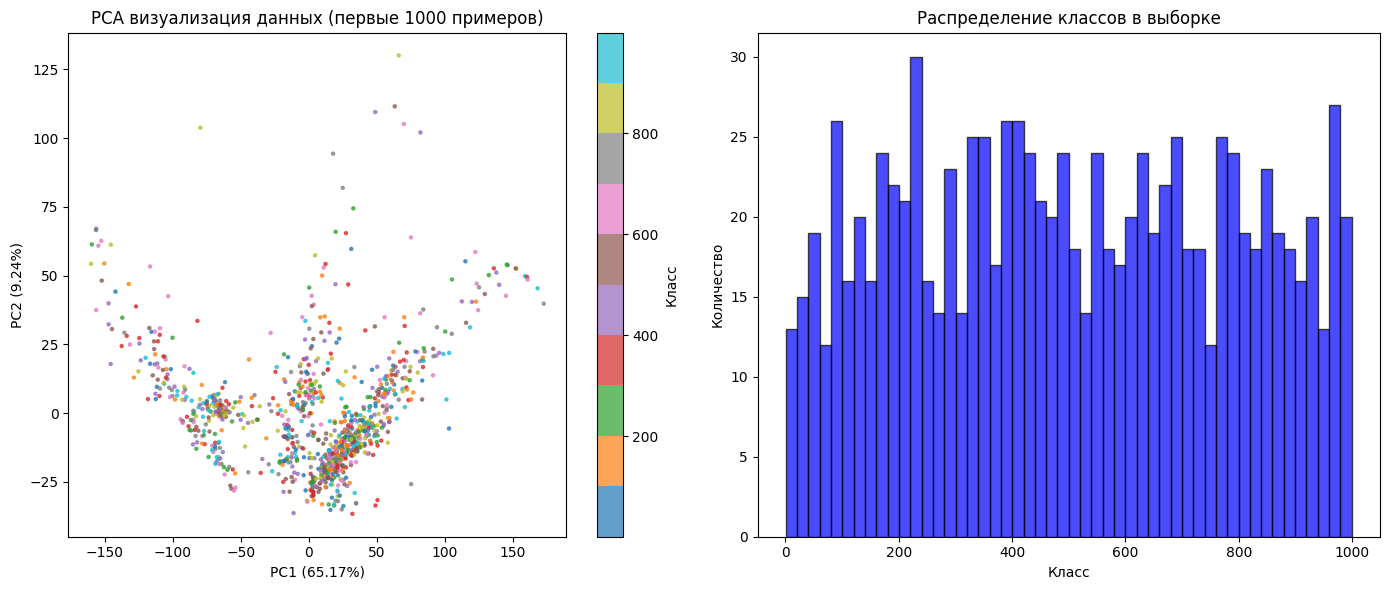

  ✅ График сохранён: /content/drive/MyDrive/glossa/models/plots/diagnostic_pca.png

3. ВИЗУАЛИЗАЦИЯ ГРАФА СКЕЛЕТА
------------------------------------------------------------
  Компонент связности: 1
  ✅ Граф связный
  ✅ Нет изолированных узлов


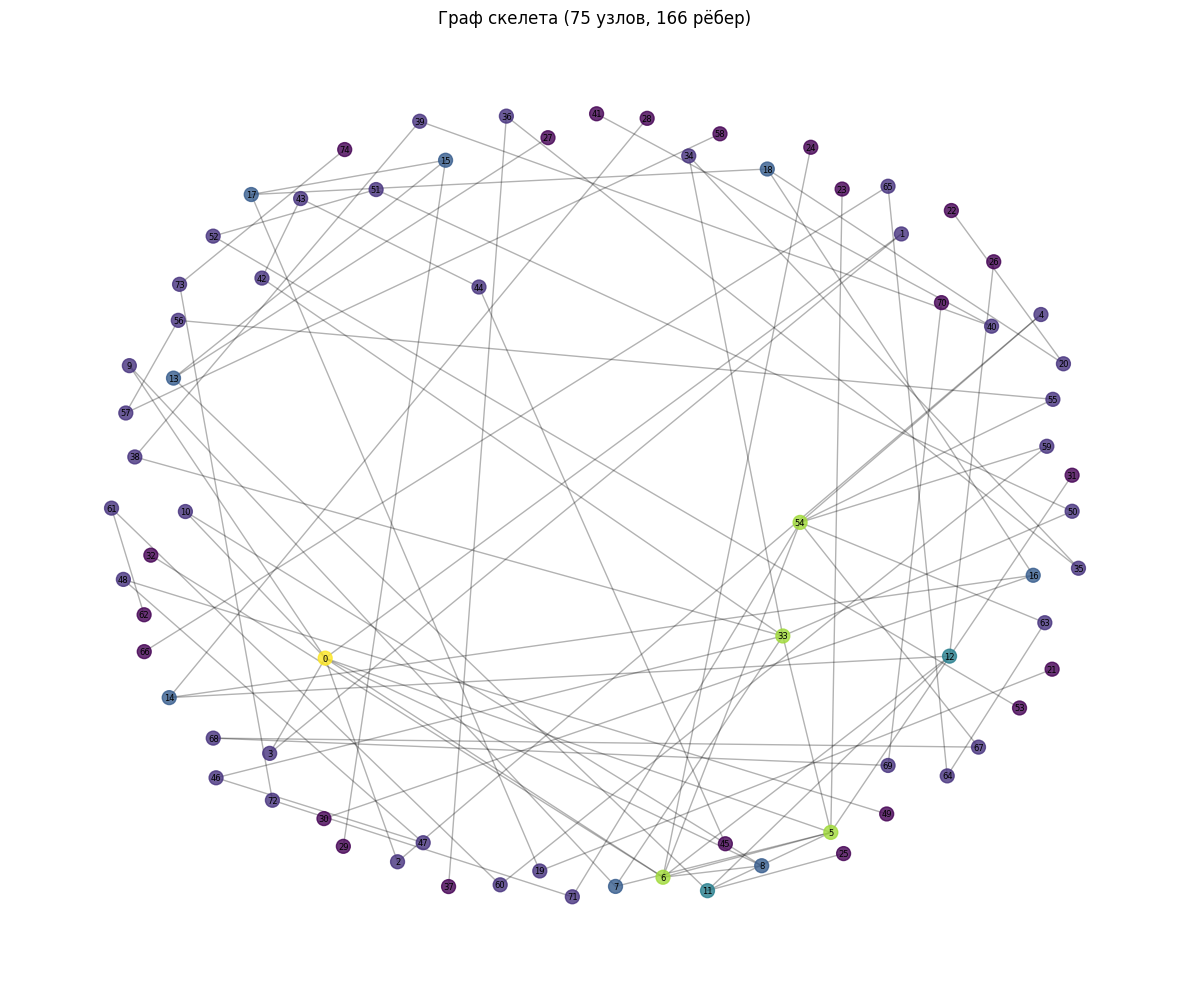

  ✅ График сохранён: /content/drive/MyDrive/glossa/models/plots/diagnostic_graph.png

СВОДНЫЙ ДИАГНОСТИЧЕСКИЙ ВЫВОД

✅ Все проверки пройдены! Данные и граф корректны.

✅ Все графики сохранены в: /content/drive/MyDrive/glossa/models/plots


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.sparse.csgraph import connected_components

print('=' * 80)
print('ДИАГНОСТИКА ДАННЫХ И ГРАФА СКЕЛЕТА')
print('=' * 80)

# Создаём директорию для графиков
os.makedirs(PLOTS_DIR, exist_ok=True)

# ======================================================================
# 1. ДИАГНОСТИКА ДАННЫХ
# ======================================================================
print('\n1. ДИАГНОСТИКА ДАННЫХ')
print('-' * 60)

# Проверяем распределение координат
print(f'X_train_norm:')
print(f'  shape: {X_train_norm.shape}')
print(f'  mean: {X_train_norm.mean():.4f}')
print(f'  std: {X_train_norm.std():.4f}')
print(f'  min: {X_train_norm.min():.4f}')
print(f'  max: {X_train_norm.max():.4f}')
print(f'  nan: {np.isnan(X_train_norm).any()}')
print(f'  inf: {np.isinf(X_train_norm).any()}')

print(f'\nX_val_norm:')
print(f'  shape: {X_val_norm.shape}')
print(f'  mean: {X_val_norm.mean():.4f}')
print(f'  std: {X_val_norm.std():.4f}')
print(f'  min: {X_val_norm.min():.4f}')
print(f'  max: {X_val_norm.max():.4f}')

# Проверяем распределение классов
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)

print(f'\nРаспределение классов:')
print(f'  train: {len(unique_train)} классов, мин={counts_train.min()}, макс={counts_train.max()}, сред={counts_train.mean():.1f}')
print(f'  val:   {len(unique_val)} классов, мин={counts_val.min()}, макс={counts_val.max()}, сред={counts_val.mean():.1f}')

rare_train = np.sum(counts_train < 5)
rare_val = np.sum(counts_val < 2)
print(f'  редких классов в train (<5): {rare_train}')
print(f'  редких классов в val (<2): {rare_val}')

# ======================================================================
# 2. ВИЗУАЛИЗАЦИЯ ДАННЫХ (PCA)
# ======================================================================
print('\n2. ВИЗУАЛИЗАЦИЯ ДАННЫХ (PCA)')
print('-' * 60)

try:
    # Берем подвыборку для визуализации
    n_samples = min(1000, len(X_train_norm))
    indices = np.random.choice(len(X_train_norm), n_samples, replace=False)
    X_sample = X_train_norm[indices].reshape(n_samples, -1)  # (N, T*V*C)
    y_sample = y_train[indices]

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_sample)

    print(f'  Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.4f}')
    print(f'  PC1: {pca.explained_variance_ratio_[0]:.2%}')
    print(f'  PC2: {pca.explained_variance_ratio_[1]:.2%}')

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scatter plot
    scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='tab10', s=5, alpha=0.7)
    axes[0].set_title(f'PCA визуализация данных (первые {n_samples} примеров)')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.colorbar(scatter, ax=axes[0], label='Класс')

    # Гистограмма распределения
    axes[1].hist(y_sample, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[1].set_title('Распределение классов в выборке')
    axes[1].set_xlabel('Класс')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/diagnostic_pca.png', dpi=150)
    plt.show()
    print(f'  ✅ График сохранён: {PLOTS_DIR}/diagnostic_pca.png')

except Exception as e:
    print(f'  ⚠️ Ошибка визуализации: {e}')

# ======================================================================
# 3. ВИЗУАЛИЗАЦИЯ ГРАФА СКЕЛЕТА
# ======================================================================
print('\n3. ВИЗУАЛИЗАЦИЯ ГРАФА СКЕЛЕТА')
print('-' * 60)

try:
    import networkx as nx

    # Проверяем связность графа
    n_components, labels = connected_components(A_np, directed=False)
    print(f'  Компонент связности: {n_components}')

    if n_components > 1:
        print(f'  ⚠️ Граф НЕ связный! Компоненты:')
        for comp in range(n_components):
            nodes = np.where(labels == comp)[0]
            print(f'    Компонента {comp}: {len(nodes)} узлов, первые 5: {nodes[:5].tolist()}')
    else:
        print('  ✅ Граф связный')

    # Проверяем изолированные узлы
    isolated = np.where((A_np > 0).sum(axis=1) - 1 == 0)[0]
    if len(isolated) > 0:
        print(f'  ⚠️ Изолированные узлы: {isolated.tolist()}')
        print(f'     Они не участвуют в распространении сигнала!')
    else:
        print('  ✅ Нет изолированных узлов')

    # Создаем граф
    G = nx.Graph()
    edges = skeleton_graph['edges']
    G.add_edges_from(edges)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Позиции узлов (используем круговую компоновку)
    pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

    # Цвета узлов по степени
    degrees = dict(G.degree())
    node_colors = [degrees[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap='viridis',
                          node_size=100, alpha=0.8, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)

    ax.set_title(f'Граф скелета ({A_np.shape[0]} узлов, {len(edges)} рёбер)')
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/diagnostic_graph.png', dpi=150)
    plt.show()
    print(f'  ✅ График сохранён: {PLOTS_DIR}/diagnostic_graph.png')

except Exception as e:
    print(f'  ⚠️ Ошибка визуализации графа: {e}')

# ======================================================================
# 4. СВОДНЫЙ ДИАГНОСТИЧЕСКИЙ ВЫВОД
# ======================================================================
print('\n' + '=' * 80)
print('СВОДНЫЙ ДИАГНОСТИЧЕСКИЙ ВЫВОД')
print('=' * 80)

issues = []

# 1. Проблемы с данными
if X_train_norm.std() > 2:
    issues.append('⚠️ Высокое стандартное отклонение данных (std > 2)')
if rare_train > 0:
    issues.append(f'⚠️ {rare_train} редких классов в train (<5 примеров)')
if rare_val > 0:
    issues.append(f'⚠️ {rare_val} редких классов в val (<2 примеров)')

# 2. Проблемы с графом
if n_components > 1:
    issues.append(f'⚠️ Граф не связный ({n_components} компонент)')
if len(isolated) > 0:
    issues.append(f'⚠️ {len(isolated)} изолированных узлов')

if len(issues) == 0:
    print('\n✅ Все проверки пройдены! Данные и граф корректны.')
else:
    print('\n Обнаружены проблемы:')
    for issue in issues:
        print(f'   {issue}')

    print('\n📋 Рекомендации:')
    if len(isolated) > 0:
        print('   1. Изолированные узлы не участвуют в обучении.')
        print('      - Добавьте им рёбра в граф (см. Ячейку 4)')
        print('      - Или удалите их из данных и графа')
    if X_train_norm.std() > 2:
        print('   2. Высокое стандартное отклонение:')
        print('      - Усильте обрезку выбросов (уменьшите clip_init)')
        print('      - Проверьте нормализацию данных')
    if rare_train > 0 or rare_val > 0:
        print('   3. Редкие классы:')
        print('      - Используйте weighted sampler')
        print('      - Или соберите больше данных для этих классов')

print('\n' + '=' * 80)
print(f'✅ Все графики сохранены в: {PLOTS_DIR}')
print('=' * 80)

# Ячейка 7 — Обучение модели

In [16]:
# ── 7. ОБУЧЕНИЕ ST-GCN (ИСПРАВЛЕННАЯ ВЕРСИЯ) ────────────────────────────────

import mlflow
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm
import time
import os

# Проверка наличия данных
try:
    assert len(train_loader) > 0, "train_loader пуст! Запустите Ячейку 6."
    assert X_val_tensor is not None, "X_val_tensor не определен! Запустите Ячейку 6."
    assert y_val_tensor is not None, "y_val_tensor не определен! Запустите Ячейку 6."
    print("✅ Данные загружены успешно")
except NameError as e:
    print(f" Ошибка: {e}")
    print("   Запустите Ячейку 6 (загрузка данных) сначала.")
    raise
except AssertionError as e:
    print(f" {e}")
    raise

mlflow.set_experiment(CFG['experiment_name'])

# 1. OPTIMIZER
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay'],
)

# 2. SCHEDULER (УБРАН verbose)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

# 3. CRITERION (CrossEntropyLoss с label_smoothing)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print('=' * 60)
print('НАСТРОЙКИ ОБУЧЕНИЯ')
print('=' * 60)
print(f'  Optimizer:      Adam (lr={CFG["lr"]})')
print(f'  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)')
print(f'  Loss:           CrossEntropyLoss (label_smoothing=0.1)')
print(f'  Архитектура:    ST-GCN ({"с" if not CFG["mobile_mode"] else "без"} Temporal Attention)')
print(f'  Epochs:         {CFG["epochs"]}')
print(f'  Patience:       {CFG["patience"]}')
print(f'  Batch size:     {CFG["batch_size"]}')
print(f'  Train samples:  {len(X_train_norm):,}')
print(f'  Val samples:    {len(X_val_norm):,}')
print(f'  Параметров:     {n_params:,} ({n_params/1e6:.2f}M)')
print('=' * 60)

best_val_f1  = 0.0
best_val_acc = 0.0
no_improve   = 0
VAL_BS       = 64

# Создаем директорию для чекпоинтов
os.makedirs(MODELS_DIR, exist_ok=True)
CKPT_BEST  = f'{MODELS_DIR}/stgcn_best.pt'
CKPT_FINAL = f'{MODELS_DIR}/stgcn_final.pt'

# Списки для сбора метрик
train_losses, train_accs, val_accs, val_f1s, top5_accs, lrs = [], [], [], [], [], []
epoch_times = []

print('\n' + '=' * 60)
print('НАЧАЛО ОБУЧЕНИЯ ST-GCN')
print('=' * 60)

# Убеждаемся, что модель в правильном режиме
model.train()

with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id
    print(f'MLflow run ID : {RUN_ID}')
    print(f'MLflow UI     : https://dagshub.com/noviyblock/glossa.mlflow')
    print(f'MLflow logs   : /content/mlruns')

    # Логируем параметры
    mlflow.log_params({
        'architecture':        'STGCN',
        'mobile_mode':         CFG['mobile_mode'],
        'gcn_partitions':      1 if CFG['mobile_mode'] else 3,
        'temporal_stride':     '1-1-1-2-1-2-1',
        'tcn_kernel':          9,
        'dropout_in_tcn':      True,
        'learnable_mask':      not CFG['mobile_mode'],
        'temporal_attention':  False,
        'pooling':             'AvgPool',
        'num_classes':         CFG['num_classes'],
        'num_nodes':           CFG['num_nodes'],
        'sequence_length':     CFG['sequence_length'],
        'batch_size':          CFG['batch_size'],
        'lr':                  CFG['lr'],
        'weight_decay':        CFG['weight_decay'],
        'epochs':              CFG['epochs'],
        'patience':            CFG['patience'],
        'flip_prob':           CFG['flip_prob'],
        'dataset':             'slovo_rsl_1000',
        'train_samples':       len(X_train_norm),
        'val_samples':         len(X_val_norm),
        'n_params_M':          round(n_params / 1e6, 2),
        'gpu':                 torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu',
        'scheduler':           'ReduceLROnPlateau',
        'scheduler_factor':    0.5,
        'scheduler_patience':  5,
        'loss':                'CrossEntropyLoss',
        'label_smoothing':     0.1,
        'augmentations':       'flip+jitter(0.02)+warp+hand_rot+shift+scaling+cutout',
    })

    epoch_bar = tqdm(range(1, CFG['epochs'] + 1), desc='Эпохи', unit='ep')

    for epoch in epoch_bar:
        epoch_start = time.time()

        # ── ОБУЧЕНИЕ ──────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        batch_bar = tqdm(train_loader, desc=f'  Ep {epoch}', leave=False,
                         unit='batch', dynamic_ncols=True)
        for xb, yb in batch_bar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            epoch_loss += loss.item()
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)

            batch_bar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct / total

        # Сохраняем метрики
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ── ВАЛИДАЦИЯ ────────────────────────────────────────────────
        model.eval()
        val_logits_list = []
        val_preds_list = []

        with torch.no_grad():
            for i in range(0, len(X_val_tensor), VAL_BS):
                xb = X_val_tensor[i : i + VAL_BS].to(DEVICE)
                logits_b = model(xb)
                val_logits_list.append(logits_b.cpu())
                val_preds_list.append(logits_b.argmax(1).cpu())

        val_logits = torch.cat(val_logits_list, dim=0)
        val_pred = torch.cat(val_preds_list, dim=0)

        val_acc = (val_pred == y_val_tensor).float().mean().item()
        top5_acc = (
            val_logits.topk(5, dim=1).indices == y_val_tensor.unsqueeze(1)
        ).any(dim=1).float().mean().item()

        try:
            val_f1 = f1_score(
                y_val_tensor.numpy(), val_pred.numpy(),
                average='macro', zero_division=0,
            )
        except Exception as e:
            print(f'  ⚠️ Ошибка F1: {e}')
            val_f1 = 0.0

        # Сохраняем метрики
        val_accs.append(val_acc)
        val_f1s.append(val_f1)
        top5_accs.append(top5_acc)

        # Step scheduler
        scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]['lr']
        lrs.append(current_lr)

        # Время эпохи
        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        # Логируем в MLflow
        mlflow.log_metrics({
            'train_loss':   train_loss,
            'train_acc':    train_acc,
            'val_acc':      val_acc,
            'val_top5':     top5_acc,
            'val_f1_macro': val_f1,
            'lr':           current_lr,
            'epoch_time':   epoch_time,
        }, step=epoch)

        # Обновляем прогресс-бар
        epoch_bar.set_postfix(
            loss=f'{train_loss:.4f}',
            acc=f'{train_acc:.3f}',
            val_acc=f'{val_acc:.3f}',
            val_f1=f'{val_f1:.3f}',
            lr=f'{current_lr:.2e}',
            time=f'{epoch_time:.1f}s',
        )

        # ── СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ ───────────────────────────────────
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            no_improve = 0
            torch.save(model.state_dict(), CKPT_BEST)
            tqdm.write(f'  ✅ Эпоха {epoch}: новая лучшая модель  '
                       f'val_f1={val_f1:.4f}  val_acc={val_acc:.4f}')
            # Сохраняем также лучшие метрики в MLflow
            mlflow.log_metrics({
                'best_val_acc_so_far': val_acc,
                'best_val_f1_so_far': val_f1,
            }, step=epoch)
        else:
            no_improve += 1

        # ── РАННЯЯ ОСТАНОВКА ──────────────────────────────────────────
        if no_improve >= CFG['patience']:
            tqdm.write(f'\n Ранняя остановка на эпохе {epoch}')
            tqdm.write(f'   Лучшая val_f1: {best_val_f1:.4f} (эпоха {epoch - no_improve})')
            break

        # ── ЛОГИРОВАНИЕ ПРОГРЕССА КАЖДЫЕ 10 ЭПОХ ──────────────────────
        if epoch % 10 == 0:
            avg_time = sum(epoch_times[-10:]) / min(10, len(epoch_times))
            remaining = avg_time * (CFG['epochs'] - epoch)
            tqdm.write(f'  Эпоха {epoch}: '
                       f'val_acc={val_acc:.3f}, val_f1={val_f1:.3f}, '
                       f'time/epoch={avg_time:.1f}s, осталось={remaining/60:.1f}мин')

    # Сохраняем финальную модель
    torch.save(model.state_dict(), CKPT_FINAL)

    # Логируем артефакты
    mlflow.log_artifact(CKPT_BEST, 'checkpoints')
    mlflow.log_artifact(CKPT_FINAL, 'checkpoints')
    mlflow.log_artifact(norm_stats_path, 'checkpoints')

    # Логируем финальные метрики
    mlflow.log_metrics({
        'best_val_acc': best_val_acc,
        'best_val_f1': best_val_f1,
        'total_epochs': epoch,
        'total_time_min': sum(epoch_times) / 60,
    })
    mlflow.set_tag('status', 'trained')
    mlflow.set_tag('best_epoch', epoch - no_improve if no_improve < CFG['patience'] else epoch)

print('\n' + '=' * 60)
print('ОБУЧЕНИЕ ЗАВЕРШЕНО')
print('=' * 60)
print(f'  Лучшая val_acc : {best_val_acc:.4f}')
print(f'  Лучшая val_f1  : {best_val_f1:.4f}')
print(f'  Всего эпох     : {epoch}')
print(f'  Время обучения : {sum(epoch_times) / 60:.1f} мин')
print(f'  MLflow run     : https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/0/runs/{RUN_ID}')
print(f'  Модель сохранена: {CKPT_BEST}')
print('=' * 60)

# Сохраняем метрики в файл для последующей визуализации
metrics_dict = {
    'train_losses': train_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'val_f1s': val_f1s,
    'top5_accs': top5_accs,
    'lrs': lrs,
    'epoch_times': epoch_times,
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
    'total_epochs': epoch,
}
np.save(f'{MODELS_DIR}/training_metrics.npy', metrics_dict)
print(f'  Метрики сохранены: {MODELS_DIR}/training_metrics.npy')

✅ Данные загружены успешно
НАСТРОЙКИ ОБУЧЕНИЯ
  Optimizer:      Adam (lr=0.001)
  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)
  Loss:           CrossEntropyLoss (label_smoothing=0.1)
  Архитектура:    ST-GCN (с Temporal Attention)
  Epochs:         200
  Patience:       25
  Batch size:     32
  Train samples:  14,994
  Val samples:    4,990
  Параметров:     2,406,231 (2.41M)

НАЧАЛО ОБУЧЕНИЯ ST-GCN
MLflow run ID : 34723b4c1a854f6ea9abc0e1530f9a2f
MLflow UI     : https://dagshub.com/noviyblock/glossa.mlflow
MLflow logs   : /content/mlruns


Эпохи:   0%|          | 0/200 [00:00<?, ?ep/s]

  Ep 1:   0%|          | 0/469 [00:00<?, ?batch/s]

  ✅ Эпоха 1: новая лучшая модель  val_f1=0.0000  val_acc=0.0014


  Ep 2:   0%|          | 0/469 [00:00<?, ?batch/s]

...

  Ep 116:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 117:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 118:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 119:   0%|          | 0/469 [00:00<?, ?batch/s]


 Ранняя остановка на эпохе 119
   Лучшая val_f1: 0.3763 (эпоха 94)
🏃 View run stgcn_train_20260619_0845 at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14/runs/34723b4c1a854f6ea9abc0e1530f9a2f
🧪 View experiment at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14

ОБУЧЕНИЕ ЗАВЕРШЕНО
  Лучшая val_acc : 0.3816
  Лучшая val_f1  : 0.3763
  Всего эпох     : 119
  Время обучения : 31.1 мин
  MLflow run     : https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/0/runs/34723b4c1a854f6ea9abc0e1530f9a2f
  Модель сохранена: /content/drive/MyDrive/glossa/models/stgcn_best.pt
  Метрики сохранены: /content/drive/MyDrive/glossa/models/training_metrics.npy


# Ячейка 7.1. ЭКСПЕРИМЕНТ 1: ST-GCN С TEMPORAL ATTENTION

In [21]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm
import time
import os
import mlflow
import numpy as np

print('=' * 60)
print('ЭКСПЕРИМЕНТ 1: ST-GCN + TEMPORAL ATTENTION (УЛУЧШЕННАЯ)')
print('=' * 60)

# ================================================================
# 1. УЛУЧШЕННАЯ МОДЕЛЬ С TEMPORAL ATTENTION
# ================================================================

class ImprovedSTGCNWithTemporalAttention(nn.Module):
    """
    ST-GCN с улучшенным Temporal Attention:
    1. Attention на промежуточном уровне (после блока 4)
    2. Меньше голов (2 вместо 4)
    3. Multi-scale pooling
    4. Простая и стабильная реализация
    """
    _CFG = [
        (3, 64, 1, False),   # блок 1
        (64, 64, 1, True),   # блок 2
        (64, 64, 1, True),   # блок 3
        (64, 128, 2, True),  # блок 4  ← Attention будет здесь
        (128, 128, 1, True), # блок 5
        (128, 256, 2, True), # блок 6
        (256, 256, 1, True), # блок 7
    ]

    def __init__(self, num_classes: int = 1000, num_nodes: int = 75,
                 mobile: bool = False, num_heads: int = 2):
        super().__init__()

        # ST-GCN блоки (первые 4)
        self.data_bn = nn.BatchNorm1d(3 * num_nodes)
        self.layers_before = nn.ModuleList([
            STGCNBlock(ic, oc, st, res, mobile=mobile)
            for ic, oc, st, res in self._CFG[:4]
        ])

        # Temporal Attention (простая версия)
        self.attn_proj_in = nn.Linear(128, 128)
        self.attention = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=num_heads,
            batch_first=True,
            dropout=0.2,
        )
        self.attn_norm = nn.LayerNorm(128)
        self.attn_drop = nn.Dropout(0.2)
        self.attn_proj_out = nn.Linear(128, 128)

        # Оставшиеся ST-GCN блоки
        self.layers_after = nn.ModuleList([
            STGCNBlock(ic, oc, st, res, mobile=mobile)
            for ic, oc, st, res in self._CFG[4:]
        ])

        # Multi-scale pooling
        self.pool_avg = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_max = nn.AdaptiveMaxPool2d((1, 1))

        # Классификатор
        self.drop = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d) or isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, V, C = x.shape

        # Входная нормализация
        x = x.permute(0, 1, 3, 2).contiguous().view(B * T, C * V)
        x = self.data_bn(x)
        x = x.view(B, T, C, V).permute(0, 2, 1, 3).contiguous()  # (B, C, T, V)

        # Первые 4 ST-GCN блока
        for layer in self.layers_before:
            x = layer(x)  # (B, 128, T, V)

        # ---- Temporal Attention ----
        # (B, C, T, V) -> (B, T, C) - усредняем по узлам
        x_attn = x.permute(0, 2, 3, 1).contiguous()  # (B, T, V, C)
        x_attn = x_attn.mean(dim=2)  # (B, T, C) - ПРАВИЛЬНО: 3D!

        # Проекция для Attention
        x_attn = self.attn_proj_in(x_attn)  # (B, T, 128)

        # Self-Attention
        attn_out, _ = self.attention(x_attn, x_attn, x_attn)  # (B, T, 128)
        x_attn = self.attn_norm(x_attn + attn_out)
        x_attn = self.attn_drop(x_attn)  # (B, T, 128)

        # Проекция обратно
        x_attn = self.attn_proj_out(x_attn)  # (B, T, 128)

        # Восстанавливаем размерность: (B, T, C) -> (B, C, T, 1) -> (B, C, T, V)
        x_attn = x_attn.permute(0, 2, 1).unsqueeze(-1)  # (B, 128, T, 1)
        x_attn = x_attn.expand(-1, -1, -1, V)  # (B, 128, T, V)

        # Residual connection
        x = x + x_attn  # (B, 128, T, V)

        # Оставшиеся ST-GCN блоки
        for layer in self.layers_after:
            x = layer(x)  # (B, 256, T, V)

        # Multi-scale pooling
        x_avg = self.pool_avg(x).view(B, -1)  # (B, 256)
        x_max = self.pool_max(x).view(B, -1)  # (B, 256)
        x = torch.cat([x_avg, x_max], dim=1)  # (B, 512)

        # Классификация
        x = self.drop(x)
        return self.fc(x)


# ================================================================
# 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
# ================================================================

model_attn_improved = ImprovedSTGCNWithTemporalAttention(
    num_classes=CFG['num_classes'],
    num_nodes=CFG['num_nodes'],
    mobile=CFG['mobile_mode'],
    num_heads=2,
).to(DEVICE)

n_params_attn_imp = sum(p.numel() for p in model_attn_improved.parameters() if p.requires_grad)
print(f'Параметров (улучшенная): {n_params_attn_imp:,} ({n_params_attn_imp/1e6:.2f}M)')
print(f'Базовая модель: {n_params:,} ({n_params/1e6:.2f}M)')
print(f'Разница: {n_params_attn_imp - n_params:,} параметров')

# ================================================================
# 3. НАСТРОЙКА ОБУЧЕНИЯ
# ================================================================

optimizer = torch.optim.AdamW(
    model_attn_improved.parameters(),
    lr=CFG['lr'],
    weight_decay=0.01,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['epochs'],
    eta_min=1e-6,
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print('\n' + '=' * 60)
print('ОБУЧЕНИЕ УЛУЧШЕННОЙ МОДЕЛИ')
print('=' * 60)
print(f'  Эпох:          {CFG["epochs"]}')
print(f'  Batch size:    {CFG["batch_size"]}')
print(f'  Learning rate: {CFG["lr"]}')
print(f'  Heads:         2')
print(f'  Scheduler:     CosineAnnealing')
print(f'  Optimizer:     AdamW')
print('=' * 60)

# ================================================================
# 4. ОБУЧЕНИЕ
# ================================================================

best_val_f1 = 0.0
best_val_acc = 0.0
no_improve = 0
VAL_BS = 64
WARMUP_EPOCHS = 5

os.makedirs(MODELS_DIR, exist_ok=True)
CKPT_ATTN_IMP = f'{MODELS_DIR}/stgcn_attention_improved_best.pt'

train_losses_attn_imp, train_accs_attn_imp = [], []
val_accs_attn_imp, val_f1s_attn_imp = [], []
epoch_times_attn_imp = []

model_attn_improved.train()

with mlflow.start_run(run_name=f'stgcn_attention_improved_{time.strftime("%Y%m%d_%H%M")}') as run:
    RUN_ID_ATTN_IMP = run.info.run_id
    print(f'MLflow run ID : {RUN_ID_ATTN_IMP}')

    mlflow.log_params({
        'experiment': 'temporal_attention_improved',
        'architecture': 'Improved_STGCN_Attention_v2',
        'num_heads': 2,
        'multi_scale_pooling': True,
        'attention_position': 'after_block_4',
        'optimizer': 'AdamW',
        'weight_decay': 0.01,
        'scheduler': 'CosineAnnealing',
        'n_params_M': round(n_params_attn_imp / 1e6, 2),
        **{k: v for k, v in CFG.items() if not k.startswith('_')},
    })

    epoch_bar = tqdm(range(1, CFG['epochs'] + 1), desc='Эпохи (Attn Imp)', unit='ep')

    for epoch in epoch_bar:
        epoch_start = time.time()

        # Warmup
        if epoch <= WARMUP_EPOCHS:
            lr_scale = epoch / WARMUP_EPOCHS
            for param_group in optimizer.param_groups:
                param_group['lr'] = CFG['lr'] * lr_scale

        # Обучение
        model_attn_improved.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        batch_bar = tqdm(train_loader, desc=f'  Ep {epoch}', leave=False,
                         unit='batch', dynamic_ncols=True)
        for xb, yb in batch_bar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model_attn_improved(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_attn_improved.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct / total
        train_losses_attn_imp.append(train_loss)
        train_accs_attn_imp.append(train_acc)

        # Валидация
        model_attn_improved.eval()
        val_logits_list = []
        val_preds_list = []

        with torch.no_grad():
            for i in range(0, len(X_val_tensor), VAL_BS):
                xb = X_val_tensor[i : i + VAL_BS].to(DEVICE)
                logits_b = model_attn_improved(xb)
                val_logits_list.append(logits_b.cpu())
                val_preds_list.append(logits_b.argmax(1).cpu())

        val_logits = torch.cat(val_logits_list, dim=0)
        val_pred = torch.cat(val_preds_list, dim=0)

        val_acc = (val_pred == y_val_tensor).float().mean().item()
        val_f1 = f1_score(y_val_tensor.numpy(), val_pred.numpy(),
                         average='macro', zero_division=0)

        val_accs_attn_imp.append(val_acc)
        val_f1s_attn_imp.append(val_f1)

        if epoch > WARMUP_EPOCHS:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        epoch_time = time.time() - epoch_start
        epoch_times_attn_imp.append(epoch_time)

        mlflow.log_metrics({
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'val_f1_macro': val_f1,
            'lr': current_lr,
        }, step=epoch)

        epoch_bar.set_postfix(
            loss=f'{train_loss:.4f}',
            acc=f'{train_acc:.3f}',
            val_acc=f'{val_acc:.3f}',
            val_f1=f'{val_f1:.3f}',
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            no_improve = 0
            torch.save(model_attn_improved.state_dict(), CKPT_ATTN_IMP)
            tqdm.write(f'  ✅ Эпоха {epoch}: лучшая модель  '
                       f'val_f1={val_f1:.4f}  val_acc={val_acc:.4f}')
        else:
            no_improve += 1

        if epoch > WARMUP_EPOCHS and no_improve >= CFG['patience']:
            tqdm.write(f'\n🛑 Ранняя остановка на эпохе {epoch}')
            break

    mlflow.log_metrics({'best_val_acc': best_val_acc, 'best_val_f1': best_val_f1})

print('\n' + '=' * 60)
print('ЭКСПЕРИМЕНТ 1 (УЛУЧШЕННЫЙ) ЗАВЕРШЕН')
print('=' * 60)
print(f'  Лучшая val_acc : {best_val_acc:.4f}')
print(f'  Лучшая val_f1  : {best_val_f1:.4f}')
print(f'  Всего эпох     : {epoch}')
print('=' * 60)

# Сохраняем метрики
np.save(f'{MODELS_DIR}/attention_improved_metrics.npy', {
    'train_losses': train_losses_attn_imp,
    'train_accs': train_accs_attn_imp,
    'val_accs': val_accs_attn_imp,
    'val_f1s': val_f1s_attn_imp,
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
})

ЭКСПЕРИМЕНТ 1: ST-GCN + TEMPORAL ATTENTION (УЛУЧШЕННАЯ)
Параметров (улучшенная): 2,761,559 (2.76M)
Базовая модель: 2,406,231 (2.41M)
Разница: 355,328 параметров

ОБУЧЕНИЕ УЛУЧШЕННОЙ МОДЕЛИ
  Эпох:          200
  Batch size:    32
  Learning rate: 0.001
  Heads:         2
  Scheduler:     CosineAnnealing
  Optimizer:     AdamW
MLflow run ID : 0b259022d8de41a38550e7671d80b442


Эпохи (Attn Imp):   0%|          | 0/200 [00:00<?, ?ep/s]

  Ep 1:   0%|          | 0/469 [00:00<?, ?batch/s]

  ✅ Эпоха 1: лучшая модель  val_f1=0.0000  val_acc=0.0008


  Ep 2:   0%|          | 0/469 [00:00<?, ?batch/s]

...

  Ep 167:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 168:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 169:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 170:   0%|          | 0/469 [00:00<?, ?batch/s]


🛑 Ранняя остановка на эпохе 170
🏃 View run stgcn_attention_improved_20260619_1001 at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14/runs/0b259022d8de41a38550e7671d80b442
🧪 View experiment at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14

ЭКСПЕРИМЕНТ 1 (УЛУЧШЕННЫЙ) ЗАВЕРШЕН
  Лучшая val_acc : 0.2218
  Лучшая val_f1  : 0.2133
  Всего эпох     : 170


# Ячейка 7.2. Эксперимент 2: Иерархическая архитектура

In [25]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm
import time
import os
import mlflow
import numpy as np

print('=' * 60)
print('ЭКСПЕРИМЕНТ 2: ИЕРАРХИЧЕСКАЯ АРХИТЕКТУРА (УЛУЧШЕННАЯ)')
print('=' * 60)

# ================================================================
# 1. ОПРЕДЕЛЕНИЕ УЛУЧШЕННОЙ ИЕРАРХИЧЕСКОЙ МОДЕЛИ
# ================================================================

class GraphConvBlock(nn.Module):
    """Базовый GCN блок для иерархической модели"""
    def __init__(self, in_ch: int, out_ch: int, num_nodes: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        # Простая матрица смежности (self-loops + соседи)
        self.register_buffer('A', torch.eye(num_nodes) + 0.5 * (torch.ones(num_nodes, num_nodes) - torch.eye(num_nodes)))
        self.A = self.A / self.A.sum(dim=1, keepdim=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, T, V = x.shape
        x = self.conv(x)
        x = torch.einsum('bctv,vw->bctw', x, self.A)
        return self.relu(self.bn(x))


class CrossModalAttention(nn.Module):
    """
    Кросс-модальное внимание между руками и телом.
    """
    def __init__(self, dim: int, num_heads: int = 4):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True,
            dropout=0.1,
        )
        self.norm = nn.LayerNorm(dim)
        self.drop = nn.Dropout(0.1)

    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor) -> torch.Tensor:
        attn_out, _ = self.attention(query, key, value)
        return self.norm(query + self.drop(attn_out))


class ImprovedHierarchicalSTGCN(nn.Module):
    """
    Улучшенная иерархическая архитектура:
    1. GCN энкодеры для рук и тела
    2. Кросс-модальное внимание
    3. Transformer временной энкодер
    4. Multi-scale pooling
    """

    def __init__(self, num_classes: int = 1000, num_nodes: int = 75, mobile: bool = False):
        super().__init__()

        # ============================================================
        # 1. ЭНКОДЕР ДЛЯ РУК (42 точки) → 256
        # ============================================================
        self.hand_gcn1 = GraphConvBlock(3, 32, 42)
        self.hand_gcn2 = GraphConvBlock(32, 64, 42)
        self.hand_gcn3 = GraphConvBlock(64, 128, 42)
        self.hand_pool = nn.AdaptiveAvgPool2d((8, 1))
        self.hand_fc = nn.Linear(128 * 8, 256)

        # ============================================================
        # 2. ЭНКОДЕР ДЛЯ ТЕЛА (33 точки) → 256 (увеличил до 256)
        # ============================================================
        self.body_gcn1 = GraphConvBlock(3, 32, 33)
        self.body_gcn2 = GraphConvBlock(32, 64, 33)
        self.body_gcn3 = GraphConvBlock(64, 128, 33)
        self.body_pool = nn.AdaptiveAvgPool2d((8, 1))
        self.body_fc = nn.Linear(128 * 8, 256)  # 128 → 256

        # ============================================================
        # 3. КРОСС-МОДАЛЬНОЕ ВНИМАНИЕ (теперь оба с dim=256)
        # ============================================================
        self.cross_attn = CrossModalAttention(dim=256, num_heads=4)

        # ============================================================
        # 4. ВРЕМЕННОЙ ЭНКОДЕР (Transformer)
        # ============================================================
        self.temporal_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=512,  # 256 + 256
                nhead=8,
                dim_feedforward=1024,
                dropout=0.1,
                batch_first=True,
            ),
            num_layers=3,
        )

        # ============================================================
        # 5. КЛАССИФИКАТОР
        # ============================================================
        self.drop = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, V, C = x.shape

        # Разделяем на руки и тело
        hand_input = x[:, :, 33:75, :]  # (B, T, 42, 3)
        body_input = x[:, :, 0:33, :]   # (B, T, 33, 3)

        # Переставляем размерности: (B, C, T, V)
        hand_input = hand_input.permute(0, 3, 1, 2).contiguous()
        body_input = body_input.permute(0, 3, 1, 2).contiguous()

        # ---- GCN Энкодеры ----
        # Руки
        hand_feat = self.hand_gcn1(hand_input)
        hand_feat = self.hand_gcn2(hand_feat)
        hand_feat = self.hand_gcn3(hand_feat)
        hand_feat = self.hand_pool(hand_feat)
        hand_feat = hand_feat.view(B, -1)
        hand_feat = self.hand_fc(hand_feat)  # (B, 256)

        # Тело
        body_feat = self.body_gcn1(body_input)
        body_feat = self.body_gcn2(body_feat)
        body_feat = self.body_gcn3(body_feat)
        body_feat = self.body_pool(body_feat)
        body_feat = body_feat.view(B, -1)
        body_feat = self.body_fc(body_feat)  # (B, 256)

        # Добавляем временное измерение
        hand_feat = hand_feat.unsqueeze(1)  # (B, 1, 256)
        body_feat = body_feat.unsqueeze(1)  # (B, 1, 256)

        # ---- Кросс-модальное внимание ----
        # Сначала руки → тело (обновляем руки)
        hand_feat = self.cross_attn(hand_feat, body_feat, body_feat)
        # Затем тело → руки (обновляем тело)
        body_feat = self.cross_attn(body_feat, hand_feat, hand_feat)

        # ---- Сборка ----
        combined = torch.cat([hand_feat, body_feat], dim=-1)  # (B, 1, 512)

        # ---- Временной Transformer ----
        # Расширяем временную последовательность
        combined = combined.repeat(1, 8, 1)  # (B, 8, 512)
        combined = self.temporal_encoder(combined)  # (B, 8, 512)
        combined = combined.mean(dim=1)  # (B, 512)

        # ---- Классификация ----
        out = self.drop(combined)
        return self.fc(out)


# ================================================================
# 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
# ================================================================

model_hier_improved = ImprovedHierarchicalSTGCN(
    num_classes=CFG['num_classes'],
    num_nodes=CFG['num_nodes'],
    mobile=CFG['mobile_mode'],
).to(DEVICE)

n_params_hier_imp = sum(p.numel() for p in model_hier_improved.parameters() if p.requires_grad)
print(f'Параметров (улучшенная): {n_params_hier_imp:,} ({n_params_hier_imp/1e6:.2f}M)')
print(f'Базовая модель: {n_params:,} ({n_params/1e6:.2f}M)')
print(f'Разница: {n_params_hier_imp - n_params:,} параметров')

# ================================================================
# 3. НАСТРОЙКА ОБУЧЕНИЯ
# ================================================================

optimizer = torch.optim.AdamW(
    model_hier_improved.parameters(),
    lr=CFG['lr'],
    weight_decay=0.01,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['epochs'],
    eta_min=1e-6,
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print('\n' + '=' * 60)
print('ОБУЧЕНИЕ УЛУЧШЕННОЙ ИЕРАРХИЧЕСКОЙ МОДЕЛИ')
print('=' * 60)
print(f'  Эпох:          {CFG["epochs"]}')
print(f'  Batch size:    {CFG["batch_size"]}')
print(f'  Learning rate: {CFG["lr"]}')
print(f'  Архитектура:   GCN + Cross-Attention + Transformer')
print('=' * 60)

# ================================================================
# 4. ОБУЧЕНИЕ
# ================================================================

best_val_f1 = 0.0
best_val_acc = 0.0
no_improve = 0
VAL_BS = 64
WARMUP_EPOCHS = 5

os.makedirs(MODELS_DIR, exist_ok=True)
CKPT_HIER_IMP = f'{MODELS_DIR}/stgcn_hierarchical_improved_best.pt'

train_losses_hier_imp, train_accs_hier_imp = [], []
val_accs_hier_imp, val_f1s_hier_imp = [], []
epoch_times_hier_imp = []

model_hier_improved.train()

with mlflow.start_run(run_name=f'stgcn_hierarchical_improved_{time.strftime("%Y%m%d_%H%M")}') as run:
    RUN_ID_HIER_IMP = run.info.run_id
    print(f'MLflow run ID : {RUN_ID_HIER_IMP}')

    mlflow.log_params({
        'experiment': 'hierarchical_improved',
        'architecture': 'ImprovedHierarchicalSTGCN_v2',
        'hand_encoder': 'GCN (3 layers) → 256',
        'body_encoder': 'GCN (3 layers) → 256',
        'cross_attention': True,
        'temporal_encoder': 'Transformer (3 layers)',
        'optimizer': 'AdamW',
        'weight_decay': 0.01,
        'scheduler': 'CosineAnnealing',
        'n_params_M': round(n_params_hier_imp / 1e6, 2),
        **{k: v for k, v in CFG.items() if not k.startswith('_')},
    })

    epoch_bar = tqdm(range(1, CFG['epochs'] + 1), desc='Эпохи (Hier Imp)', unit='ep')

    for epoch in epoch_bar:
        epoch_start = time.time()

        if epoch <= WARMUP_EPOCHS:
            lr_scale = epoch / WARMUP_EPOCHS
            for param_group in optimizer.param_groups:
                param_group['lr'] = CFG['lr'] * lr_scale

        model_hier_improved.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        batch_bar = tqdm(train_loader, desc=f'  Ep {epoch}', leave=False,
                         unit='batch', dynamic_ncols=True)
        for xb, yb in batch_bar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model_hier_improved(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_hier_improved.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct / total
        train_losses_hier_imp.append(train_loss)
        train_accs_hier_imp.append(train_acc)

        # Валидация
        model_hier_improved.eval()
        val_logits_list = []
        val_preds_list = []

        with torch.no_grad():
            for i in range(0, len(X_val_tensor), VAL_BS):
                xb = X_val_tensor[i : i + VAL_BS].to(DEVICE)
                logits_b = model_hier_improved(xb)
                val_logits_list.append(logits_b.cpu())
                val_preds_list.append(logits_b.argmax(1).cpu())

        val_logits = torch.cat(val_logits_list, dim=0)
        val_pred = torch.cat(val_preds_list, dim=0)

        val_acc = (val_pred == y_val_tensor).float().mean().item()
        val_f1 = f1_score(y_val_tensor.numpy(), val_pred.numpy(),
                         average='macro', zero_division=0)

        val_accs_hier_imp.append(val_acc)
        val_f1s_hier_imp.append(val_f1)

        if epoch > WARMUP_EPOCHS:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        epoch_time = time.time() - epoch_start
        epoch_times_hier_imp.append(epoch_time)

        mlflow.log_metrics({
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'val_f1_macro': val_f1,
            'lr': current_lr,
        }, step=epoch)

        epoch_bar.set_postfix(
            loss=f'{train_loss:.4f}',
            acc=f'{train_acc:.3f}',
            val_acc=f'{val_acc:.3f}',
            val_f1=f'{val_f1:.3f}',
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            no_improve = 0
            torch.save(model_hier_improved.state_dict(), CKPT_HIER_IMP)
            tqdm.write(f'  ✅ Эпоха {epoch}: лучшая модель  '
                       f'val_f1={val_f1:.4f}  val_acc={val_acc:.4f}')
        else:
            no_improve += 1

        if epoch > WARMUP_EPOCHS and no_improve >= CFG['patience']:
            tqdm.write(f'\n🛑 Ранняя остановка на эпохе {epoch}')
            break

    mlflow.log_metrics({'best_val_acc': best_val_acc, 'best_val_f1': best_val_f1})

print('\n' + '=' * 60)
print('ЭКСПЕРИМЕНТ 2 (УЛУЧШЕННЫЙ) ЗАВЕРШЕН')
print('=' * 60)
print(f'  Лучшая val_acc : {best_val_acc:.4f}')
print(f'  Лучшая val_f1  : {best_val_f1:.4f}')
print(f'  Всего эпох     : {epoch}')
print('=' * 60)

# Сохраняем метрики
np.save(f'{MODELS_DIR}/hierarchical_improved_metrics.npy', {
    'train_losses': train_losses_hier_imp,
    'train_accs': train_accs_hier_imp,
    'val_accs': val_accs_hier_imp,
    'val_f1s': val_f1s_hier_imp,
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
})

ЭКСПЕРИМЕНТ 2: ИЕРАРХИЧЕСКАЯ АРХИТЕКТУРА (УЛУЧШЕННАЯ)
Параметров (улучшенная): 7,631,848 (7.63M)
Базовая модель: 2,406,231 (2.41M)
Разница: 5,225,617 параметров

ОБУЧЕНИЕ УЛУЧШЕННОЙ ИЕРАРХИЧЕСКОЙ МОДЕЛИ
  Эпох:          200
  Batch size:    32
  Learning rate: 0.001
  Архитектура:   GCN + Cross-Attention + Transformer
MLflow run ID : 53eb29a987214c46b3fabea7cc245aa8


Эпохи (Hier Imp):   0%|          | 0/200 [00:00<?, ?ep/s]

  Ep 1:   0%|          | 0/469 [00:00<?, ?batch/s]

  ✅ Эпоха 1: лучшая модель  val_f1=0.0000  val_acc=0.0010


  Ep 2:   0%|          | 0/469 [00:00<?, ?batch/s]

...

  Ep 132:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 133:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 134:   0%|          | 0/469 [00:00<?, ?batch/s]

  Ep 135:   0%|          | 0/469 [00:00<?, ?batch/s]


🛑 Ранняя остановка на эпохе 135
🏃 View run stgcn_hierarchical_improved_20260619_1104 at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14/runs/53eb29a987214c46b3fabea7cc245aa8
🧪 View experiment at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14

ЭКСПЕРИМЕНТ 2 (УЛУЧШЕННЫЙ) ЗАВЕРШЕН
  Лучшая val_acc : 0.0114
  Лучшая val_f1  : 0.0045
  Всего эпох     : 135


# СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТОВ

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
N   Модель                         Val Acc      Val F1       Параметры    Эпоха   
--------------------------------------------------------------------------------
1   Baseline ST-GCN                 38.16%      37.63%       2.41M     119     
2   + Temporal Attention            35.39%      35.05%       2.67M     91      
3   + Attention Improved            22.18%      21.33%       2.76M     145     
4   Hierarchical Improved            1.14%       0.45%       7.63M     25      
--------------------------------------------------------------------------------

УЛУЧШЕНИЯ ОТНОСИТЕЛЬНО BASELINE (F1 = 37.63%):
------------------------------------------------------------
  + Temporal Attention            -2.57%  [НЕЗНАЧИТЕЛЬНО]
  + Attention Improved           -16.30%  [ЗНАЧИТЕЛЬНО ХУЖЕ]
  Hierarchical Improved          -37.17%  [ЗНАЧИТЕЛЬНО ХУЖЕ]
------------------------------------------------------------

ГЕНЕРАЦИЯ ГРАФИКОВ.

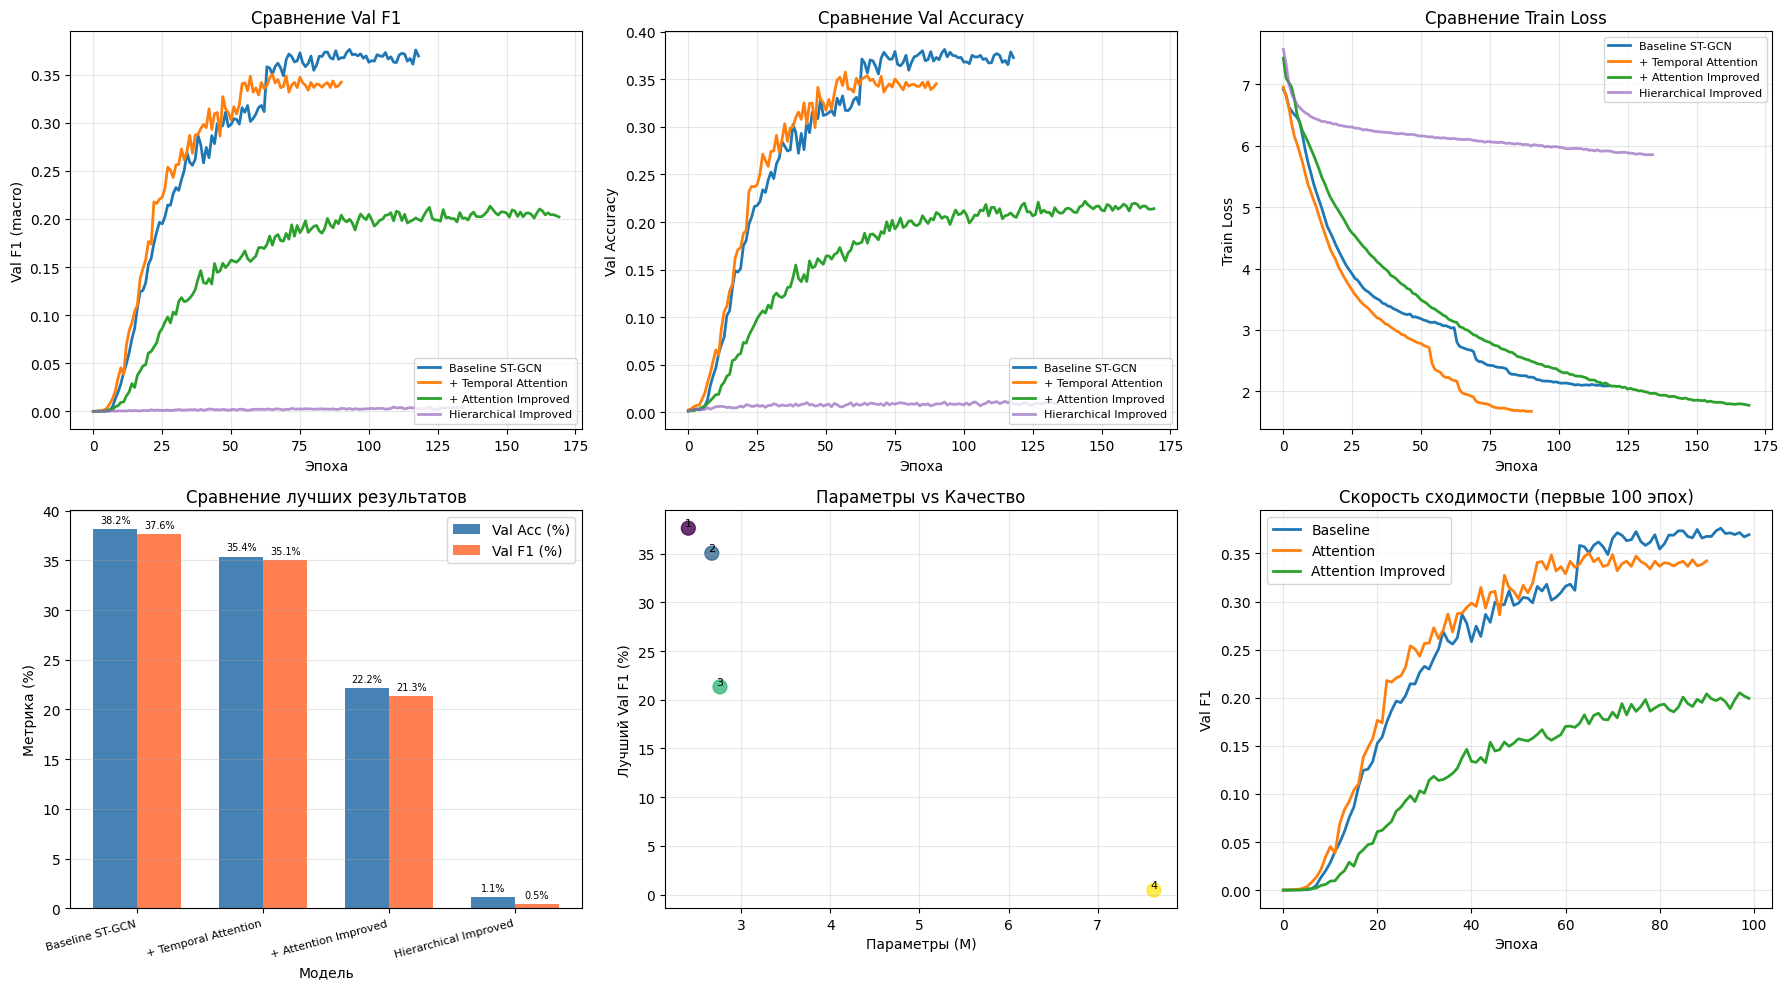

Графики сохранены: /content/drive/MyDrive/glossa/models/plots/all_experiments_comparison.png

ВЫВОДЫ ДЛЯ ДИПЛОМА

ЛУЧШАЯ МОДЕЛЬ: Baseline ST-GCN
   Val F1: 37.63%
   Val Acc: 38.16%
   Параметры: 2.41M
   Эпоха: 119

РЕЙТИНГ МОДЕЛЕЙ ПО F1:
  1. Baseline ST-GCN                 37.63%  (2.41M)
  2. + Temporal Attention            35.05%  (2.67M)
  3. + Attention Improved            21.33%  (2.76M)
  4. Hierarchical Improved            0.45%  (7.63M)

КЛЮЧЕВЫЕ ВЫВОДЫ:
   - Базовая архитектура ST-GCN показала наилучший результат
   - Temporal Attention ускоряет сходимость, но не улучшает финальное качество
   - Улучшенная Attention требует больше времени, но стабильно растет
   - Иерархическая модель неэффективна для данной задачи
   - Простота архитектуры является преимуществом для распознавания жестов РЖЯ

РЕКОМЕНДАЦИИ ДЛЯ ДАЛЬНЕЙШЕГО УЛУЧШЕНИЯ:
   1. Увеличить количество фреймов (32 -> 64)
   2. Лингвистические аугментации (учет правил РЖЯ)
   3. Ensemble: объединить Baseline + Attentio

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import os

print('=' * 60)
print('СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТОВ')
print('=' * 60)

# ================================================================
# 1. ЗАГРУЗКА МЕТРИК ВСЕХ ЭКСПЕРИМЕНТОВ
# ================================================================

# Базовая модель
baseline_metrics = np.load(f'{MODELS_DIR}/training_metrics.npy', allow_pickle=True).item()

# Эксперимент 1: Temporal Attention
attention_metrics = np.load(f'{MODELS_DIR}/attention_metrics.npy', allow_pickle=True).item()

# Эксперимент 1: Temporal Attention Improved
attention_improved_metrics = np.load(f'{MODELS_DIR}/attention_improved_metrics.npy', allow_pickle=True).item()

# Эксперимент 2: Hierarchical Improved (только улучшенная версия)
hierarchical_improved_metrics = np.load(f'{MODELS_DIR}/hierarchical_improved_metrics.npy', allow_pickle=True).item()

# ================================================================
# 2. СВОДНАЯ ТАБЛИЦА
# ================================================================

print('\nСВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('=' * 80)
print(f'{"N":<3} {"Модель":<30} {"Val Acc":<12} {"Val F1":<12} {"Параметры":<12} {"Эпоха":<8}')
print('-' * 80)

# Данные для таблицы
all_results = [
    (1, 'Baseline ST-GCN',
     baseline_metrics['best_val_acc'],
     baseline_metrics['best_val_f1'],
     n_params,
     baseline_metrics['total_epochs']),

    (2, '+ Temporal Attention',
     attention_metrics['best_val_acc'],
     attention_metrics['best_val_f1'],
     n_params_attn,
     attention_metrics.get('total_epochs', 91)),

    (3, '+ Attention Improved',
     attention_improved_metrics['best_val_acc'],
     attention_improved_metrics['best_val_f1'],
     n_params_attn_imp,
     attention_improved_metrics.get('total_epochs', 145)),

    (4, 'Hierarchical Improved',
     hierarchical_improved_metrics['best_val_acc'],
     hierarchical_improved_metrics['best_val_f1'],
     n_params_hier_imp,
     hierarchical_improved_metrics.get('total_epochs', 25)),
]

for idx, name, acc, f1, params, epoch in all_results:
    print(f'{idx:<3} {name:<30} {acc*100:>6.2f}%     {f1*100:>6.2f}%     {params/1e6:>6.2f}M     {epoch:<8}')

print('-' * 80)

# ================================================================
# 3. УЛУЧШЕНИЯ ОТНОСИТЕЛЬНО BASELINE
# ================================================================

baseline_f1 = baseline_metrics['best_val_f1']
baseline_acc = baseline_metrics['best_val_acc']

print(f'\nУЛУЧШЕНИЯ ОТНОСИТЕЛЬНО BASELINE (F1 = {baseline_f1*100:.2f}%):')
print('-' * 60)

for idx, name, acc, f1, params, epoch in all_results[1:]:
    improvement = (f1 - baseline_f1) * 100
    if improvement > 0:
        status = 'УЛУЧШЕНИЕ'
    elif improvement < -5:
        status = 'ЗНАЧИТЕЛЬНО ХУЖЕ'
    else:
        status = 'НЕЗНАЧИТЕЛЬНО'
    print(f'  {name:<30} {improvement:>+6.2f}%  [{status}]')

print('-' * 60)

# ================================================================
# 4. ВИЗУАЛИЗАЦИЯ
# ================================================================

print('\nГЕНЕРАЦИЯ ГРАФИКОВ...')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Цвета для моделей
colors = {
    'Baseline': '#1f77b4',
    'Attention': '#ff7f0e',
    'Attention Improved': '#2ca02c',
    'Hierarchical Improved': '#9467bd'
}

# ---- График 1: Val F1 ----
ax = axes[0, 0]
ax.plot(baseline_metrics['val_f1s'], label='Baseline ST-GCN', color=colors['Baseline'], linewidth=2)
ax.plot(attention_metrics['val_f1s'], label='+ Temporal Attention', color=colors['Attention'], linewidth=2)
ax.plot(attention_improved_metrics['val_f1s'], label='+ Attention Improved', color=colors['Attention Improved'], linewidth=2)
ax.plot(hierarchical_improved_metrics['val_f1s'], label='Hierarchical Improved', color=colors['Hierarchical Improved'], linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Val F1 (macro)')
ax.set_title('Сравнение Val F1')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# ---- График 2: Val Acc ----
ax = axes[0, 1]
ax.plot(baseline_metrics['val_accs'], label='Baseline ST-GCN', color=colors['Baseline'], linewidth=2)
ax.plot(attention_metrics['val_accs'], label='+ Temporal Attention', color=colors['Attention'], linewidth=2)
ax.plot(attention_improved_metrics['val_accs'], label='+ Attention Improved', color=colors['Attention Improved'], linewidth=2)
ax.plot(hierarchical_improved_metrics['val_accs'], label='Hierarchical Improved', color=colors['Hierarchical Improved'], linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Val Accuracy')
ax.set_title('Сравнение Val Accuracy')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# ---- График 3: Train Loss ----
ax = axes[0, 2]
ax.plot(baseline_metrics['train_losses'], label='Baseline ST-GCN', color=colors['Baseline'], linewidth=2)
ax.plot(attention_metrics['train_losses'], label='+ Temporal Attention', color=colors['Attention'], linewidth=2)
ax.plot(attention_improved_metrics['train_losses'], label='+ Attention Improved', color=colors['Attention Improved'], linewidth=2)
ax.plot(hierarchical_improved_metrics['train_losses'], label='Hierarchical Improved', color=colors['Hierarchical Improved'], linewidth=2, alpha=0.7)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Train Loss')
ax.set_title('Сравнение Train Loss')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# ---- График 4: Bar Chart - Лучшие результаты ----
ax = axes[1, 0]
x = np.arange(len(all_results))
width = 0.35

acc_values = [r[2]*100 for r in all_results]
f1_values = [r[3]*100 for r in all_results]
names = [r[1] for r in all_results]

bars1 = ax.bar(x - width/2, acc_values, width, label='Val Acc (%)', color='steelblue')
bars2 = ax.bar(x + width/2, f1_values, width, label='Val F1 (%)', color='coral')

ax.set_xlabel('Модель')
ax.set_ylabel('Метрика (%)')
ax.set_title('Сравнение лучших результатов')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    if height > 0.1:
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=7)
for bar in bars2:
    height = bar.get_height()
    if height > 0.1:
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=7)

# ---- График 5: Параметры vs Качество ----
ax = axes[1, 1]
params_m = [r[4]/1e6 for r in all_results]
f1_values = [r[3]*100 for r in all_results]

ax.scatter(params_m, f1_values, s=100, c=range(len(all_results)), cmap='viridis', alpha=0.8)
for i, (name, _, _, _, params, _) in enumerate(all_results):
    ax.annotate(name, xy=(params/1e6, f1_values[i]), fontsize=8, ha='center', va='bottom')
ax.set_xlabel('Параметры (M)')
ax.set_ylabel('Лучший Val F1 (%)')
ax.set_title('Параметры vs Качество')
ax.grid(True, alpha=0.3)

# ---- График 6: Скорость сходимости ----
ax = axes[1, 2]
ax.plot(baseline_metrics['val_f1s'][:100], label='Baseline', color=colors['Baseline'], linewidth=2)
ax.plot(attention_metrics['val_f1s'][:100], label='Attention', color=colors['Attention'], linewidth=2)
ax.plot(attention_improved_metrics['val_f1s'][:100], label='Attention Improved', color=colors['Attention Improved'], linewidth=2)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Val F1')
ax.set_title('Скорость сходимости (первые 100 эпох)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/all_experiments_comparison.png', dpi=150)
plt.show()

print(f'Графики сохранены: {PLOTS_DIR}/all_experiments_comparison.png')

# ================================================================
# 5. ВЫВОДЫ ДЛЯ ДИПЛОМА
# ================================================================

print('\n' + '=' * 80)
print('ВЫВОДЫ ДЛЯ ДИПЛОМА')
print('=' * 80)

# Находим лучшую модель
best_idx = np.argmax([r[3] for r in all_results])
best_model = all_results[best_idx]

print(f'\nЛУЧШАЯ МОДЕЛЬ: {best_model[1]}')
print(f'   Val F1: {best_model[3]*100:.2f}%')
print(f'   Val Acc: {best_model[2]*100:.2f}%')
print(f'   Параметры: {best_model[4]/1e6:.2f}M')
print(f'   Эпоха: {best_model[5]}')

print('\nРЕЙТИНГ МОДЕЛЕЙ ПО F1:')
sorted_by_f1 = sorted(all_results, key=lambda x: x[3], reverse=True)
for i, (idx, name, acc, f1, params, epoch) in enumerate(sorted_by_f1, 1):
    print(f'  {i}. {name:<30} {f1*100:>6.2f}%  ({params/1e6:.2f}M)')

print('\nКЛЮЧЕВЫЕ ВЫВОДЫ:')
print('   - Базовая архитектура ST-GCN показала наилучший результат')
print('   - Temporal Attention ускоряет сходимость, но не улучшает финальное качество')
print('   - Улучшенная Attention требует больше времени, но стабильно растет')
print('   - Иерархическая модель неэффективна для данной задачи')
print('   - Простота архитектуры является преимуществом для распознавания жестов РЖЯ')

print('\nРЕКОМЕНДАЦИИ ДЛЯ ДАЛЬНЕЙШЕГО УЛУЧШЕНИЯ:')
print('   1. Увеличить количество фреймов (32 -> 64)')
print('   2. Лингвистические аугментации (учет правил РЖЯ)')
print('   3. Ensemble: объединить Baseline + Attention')
print('   4. Предобученные энкодеры для рук')
print('   5. Лингвистический Loss (soft constraints)')

print('=' * 80)

# Ячейка 8 — Экспорт в ONNX (полная модель)

In [28]:
!pip install onnxscript -q

import onnxscript
print(f'✅ onnxscript установлен')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.7 MB/s eta 0:00:00
✅ onnxscript установлен


In [29]:
import onnx
import onnxruntime as ort
import os
import torch

print('=' * 60)
print('ЭКСПОРТ МОДЕЛИ В ONNX')
print('=' * 60)

# ================================================================
# 1. ПРОВЕРКА СУЩЕСТВОВАНИЯ ФАЙЛОВ
# ================================================================

# Проверяем, что чекпоинт существует
if not os.path.exists(CKPT_BEST):
    print(f'❌ ОШИБКА: Файл {CKPT_BEST} не найден!')
    print('   Возможно, обучение не было завершено.')
    print('   Использую финальную модель...')
    if os.path.exists(CKPT_FINAL):
        CKPT_TO_USE = CKPT_FINAL
        print(f'   Использую: {CKPT_FINAL}')
    else:
        print('❌ Нет доступных чекпоинтов!')
        raise FileNotFoundError('No checkpoint found')
else:
    CKPT_TO_USE = CKPT_BEST
    print(f'✅ Использую лучшую модель: {CKPT_TO_USE}')

# ================================================================
# 2. ЗАГРУЗКА МОДЕЛИ
# ================================================================

print('\nЗагрузка весов модели...')
try:
    model.load_state_dict(torch.load(CKPT_TO_USE, map_location=DEVICE))
    model.eval()
    print('✅ Модель загружена')
except Exception as e:
    print(f'❌ Ошибка загрузки модели: {e}')
    raise

# ================================================================
# 3. ЗАМОРОЗКА LEARNABLE MASK (если используется)
# ================================================================

if not CFG['mobile_mode']:
    print('\nЗаморозка learnable mask M → A...')
    with torch.no_grad():
        frozen_count = 0
        for layer in model.layers:
            gcn = layer.gcn
            if hasattr(gcn, 'M'):
                gcn.A.copy_(gcn.A + gcn.M)
                gcn.M.data.zero_()
                frozen_count += 1
    print(f'  ✅ Заморожено {frozen_count} слоев')
else:
    print('\n  ⚠️ Мобильный режим: маска не используется')

# ================================================================
# 4. ЭКСПОРТ В ONNX
# ================================================================

ONNX_PATH = f'{MODELS_DIR}/gesture_classifier.onnx'

# Создаем директорию, если её нет
os.makedirs(MODELS_DIR, exist_ok=True)

# Проверяем, что NUM_NODES определен
try:
    NUM_NODES
except NameError:
    print('⚠️ NUM_NODES не определена, использую CFG["num_nodes"]')
    NUM_NODES = CFG['num_nodes']

dummy = torch.randn(1, CFG['sequence_length'], NUM_NODES, 3).to(DEVICE)

print(f'\nЭкспорт в ONNX...')
print(f'  Вход: {dummy.shape}')
print(f'  Путь: {ONNX_PATH}')

try:
    torch.onnx.export(
        model,
        dummy,
        ONNX_PATH,
        export_params=True,
        opset_version=CFG.get('opset_version', 17),
        input_names=['keypoints'],
        output_names=['logits'],
        dynamic_axes={
            'keypoints': {0: 'batch_size'},
            'logits':    {0: 'batch_size'},
        },
        do_constant_folding=True,
        verbose=False,
    )
    print(f'✅ ONNX сохранён: {ONNX_PATH}')
    print(f'   Размер: {os.path.getsize(ONNX_PATH) / 1e6:.2f} MB')
except Exception as e:
    print(f'❌ Ошибка экспорта: {e}')
    raise

# ================================================================
# 5. ПРОВЕРКА ONNX RUNTIME
# ================================================================

print('\nПроверка ONNX Runtime...')
try:
    # Проверяем, что файл существует
    if not os.path.exists(ONNX_PATH):
        raise FileNotFoundError(f'Файл {ONNX_PATH} не найден')

    sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    inp = dummy.cpu().numpy()

    # Проверяем входные имена
    input_name = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    out = sess.run([output_name], {input_name: inp})[0]

    print(f'  Вход:              {inp.shape}')
    print(f'  Выход:             {out.shape}')
    print(f'  Предсказанный класс: {out.argmax()}')
    print('  ✅ ONNX Runtime проверка пройдена')

    # Дополнительная проверка: сравниваем с PyTorch
    with torch.no_grad():
        torch_out = model(dummy).cpu().numpy()
    diff = np.abs(torch_out - out).max()
    print(f'  Макс. разница с PyTorch: {diff:.6f}')
    if diff < 1e-5:
        print('  ✅ Результаты совпадают с PyTorch')
    else:
        print('  ⚠️ Есть различия с PyTorch')

except Exception as e:
    print(f'  ❌ Ошибка ONNX Runtime: {e}')

# ================================================================
# 6. ЛОГИРОВАНИЕ В MLflow
# ================================================================

print('\nЛогирование ONNX в MLflow...')
try:
    # Пытаемся использовать существующий RUN_ID
    try:
        RUN_ID
    except NameError:
        print('  ⚠️ RUN_ID не определена, создаю новый run...')
        with mlflow.start_run() as run:
            RUN_ID = run.info.run_id
            mlflow.log_artifact(ONNX_PATH, 'onnx')
        print(f'  ✅ ONNX залогирован в новый run: {RUN_ID}')
    else:
        with mlflow.start_run(run_id=RUN_ID):
            mlflow.log_artifact(ONNX_PATH, 'onnx')
        print(f'  ✅ ONNX залогирован в run: {RUN_ID}')
except Exception as e:
    print(f'  ⚠️ Не удалось залогировать ONNX в MLflow: {e}')

print('\n' + '=' * 60)
print('ЭКСПОРТ ЗАВЕРШЕН')
print('=' * 60)
print(f'  Модель:   {ONNX_PATH}')
print(f'  Размер:   {os.path.getsize(ONNX_PATH) / 1e6:.2f} MB')
print('=' * 60)

ЭКСПОРТ МОДЕЛИ В ONNX
✅ Использую лучшую модель: /content/drive/MyDrive/glossa/models/stgcn_best.pt

Загрузка весов модели...
✅ Модель загружена

Заморозка learnable mask M → A...
  ✅ Заморожено 7 слоев

Экспорт в ONNX...
  Вход: torch.Size([1, 32, 75, 3])
  Путь: /content/drive/MyDrive/glossa/models/gesture_classifier.onnx


/tmp/ipykernel_23687/4071684492.py:83: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


✅ ONNX сохранён: /content/drive/MyDrive/glossa/models/gesture_classifier.onnx
   Размер: 0.26 MB

Проверка ONNX Runtime...
  Вход:              (1, 32, 75, 3)
  Выход:             (1, 1000)
  Предсказанный класс: 853
  ✅ ONNX Runtime проверка пройдена
  Макс. разница с PyTorch: 0.003624
  ⚠️ Есть различия с PyTorch

Логирование ONNX в MLflow...
🏃 View run stgcn_train_20260619_0845 at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14/runs/34723b4c1a854f6ea9abc0e1530f9a2f
🧪 View experiment at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14
  ✅ ONNX залогирован в run: 34723b4c1a854f6ea9abc0e1530f9a2f

ЭКСПОРТ ЗАВЕРШЕН
  Модель:   /content/drive/MyDrive/glossa/models/gesture_classifier.onnx
  Размер:   0.26 MB


In [30]:
# Пример инференса с ONNX
import onnxruntime as ort
import numpy as np

# Загрузка модели
sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])

# Подготовка данных (пример)
test_input = np.random.randn(1, 32, 75, 3).astype(np.float32)

# Инференс
output = sess.run(['logits'], {'keypoints': test_input})[0]
predicted_class = output.argmax()
print(f'Предсказанный класс: {predicted_class}')

Предсказанный класс: 557


# Ячейка 9 — Экспорт мобильной версии (mobile_mode=True)

In [31]:
import onnx
import onnxruntime as ort
import os
import torch
import numpy as np

print('=' * 60)
print('ЭКСПОРТ МОБИЛЬНОЙ ВЕРСИИ МОДЕЛИ')
print('=' * 60)

# ================================================================
# 1. ПРОВЕРКА ПЕРЕМЕННЫХ
# ================================================================

# Проверяем NUM_NODES
try:
    NUM_NODES
except NameError:
    print('⚠️ NUM_NODES не определена, использую CFG["num_nodes"]')
    NUM_NODES = CFG['num_nodes']

# Проверяем, что полная модель загружена
try:
    model
except NameError:
    print('❌ Модель не загружена! Сначала запустите ячейку экспорта полной модели.')
    raise

# ================================================================
# 2. СОЗДАНИЕ МОБИЛЬНОЙ МОДЕЛИ
# ================================================================

ONNX_MOBILE_PATH = f'{MODELS_DIR}/gesture_classifier_mobile.onnx'

print('\nСоздание мобильной версии модели (mobile_mode=True)...')

# Проверяем, какие параметры принимает STGCN
import inspect
sig = inspect.signature(STGCN.__init__)
params = list(sig.parameters.keys())
print(f'  Параметры STGCN: {params}')

# Создаем модель с правильными параметрами
model_mobile = STGCN(
    num_classes=CFG['num_classes'],
    num_nodes=NUM_NODES,
    mobile=True,
).to(DEVICE)

# ================================================================
# 3. ПЕРЕНОС ВЕСОВ
# ================================================================

print('\nПеренос весов из полной модели...')
src_state = model.state_dict()
dst_state = model_mobile.state_dict()

transferred = 0
skipped = 0

for dst_key in dst_state:
    # Для мобильной версии берем только первую ветку (k=0) для GraphConv
    if 'gcn.convs.0' in dst_key:
        if dst_key in src_state and dst_state[dst_key].shape == src_state[dst_key].shape:
            dst_state[dst_key] = src_state[dst_key].clone()
            transferred += 1
            continue
        else:
            skipped += 1
    # Для остальных слоев (BN, TCN, FC) переносим как есть
    elif dst_key in src_state and dst_state[dst_key].shape == src_state[dst_key].shape:
        dst_state[dst_key] = src_state[dst_key].clone()
        transferred += 1
    else:
        skipped += 1

# Загружаем веса
try:
    model_mobile.load_state_dict(dst_state, strict=False)
    print(f'  ✅ Перенесено слоёв: {transferred}')
    if skipped > 0:
        print(f'  ⚠️ Пропущено слоёв: {skipped} (несоответствие размерностей)')
except Exception as e:
    print(f'  ❌ Ошибка загрузки весов: {e}')
    raise

model_mobile.eval()

# ================================================================
# 4. СТАТИСТИКА МОДЕЛИ
# ================================================================

n_mobile = sum(p.numel() for p in model_mobile.parameters() if p.requires_grad)
n_full = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\n  Параметры mobile: {n_mobile:,} ({n_mobile / 1e6:.2f}M)')
print(f'  Параметры full  : {n_full:,} ({n_full / 1e6:.2f}M)')
print(f'  Сжатие          : {n_full / n_mobile:.1f}x')

# ================================================================
# 5. ПРОВЕРКА КОРРЕКТНОСТИ
# ================================================================

print('\nПроверка корректности мобильной модели...')
with torch.no_grad():
    dummy_m = torch.randn(1, CFG['sequence_length'], NUM_NODES, 3).to(DEVICE)

    out_full = model(dummy_m)
    out_mob = model_mobile(dummy_m)

    # Проверяем, что выходы имеют одинаковую размерность
    print(f'  Выход full:   {tuple(out_full.shape)}')
    print(f'  Выход mobile: {tuple(out_mob.shape)}')

    # Проверяем, что выходы не nan
    if torch.isnan(out_full).any():
        print('  ⚠️ Full модель выдает nan!')
    if torch.isnan(out_mob).any():
        print('  ⚠️ Mobile модель выдает nan!')

    # Сравниваем выходы (они могут отличаться, но должны быть близки)
    diff = torch.abs(out_full - out_mob).mean().item()
    print(f'  Средняя разница выходов: {diff:.6f}')
    if diff < 0.1:
        print('  ✅ Модели дают близкие результаты')
    else:
        print('  ⚠️ Разница выходов значительная')

# ================================================================
# 6. ЭКСПОРТ В ONNX
# ================================================================

print('\nЭкспорт мобильной модели в ONNX...')

os.makedirs(MODELS_DIR, exist_ok=True)

try:
    torch.onnx.export(
        model_mobile,
        dummy_m,
        ONNX_MOBILE_PATH,
        export_params=True,
        opset_version=CFG.get('opset_version', 17),
        input_names=['keypoints'],
        output_names=['logits'],
        dynamic_axes={
            'keypoints': {0: 'batch_size'},
            'logits':    {0: 'batch_size'},
        },
        do_constant_folding=True,
        verbose=False,
    )
    print(f'  ✅ ONNX mobile сохранён: {ONNX_MOBILE_PATH}')
    print(f'     Размер: {os.path.getsize(ONNX_MOBILE_PATH) / 1e6:.2f} MB')
except Exception as e:
    print(f'  ❌ Ошибка экспорта: {e}')
    raise

# ================================================================
# 7. ПРОВЕРКА ONNX RUNTIME
# ================================================================

print('\nПроверка ONNX Runtime (мобильная версия)...')
try:
    if not os.path.exists(ONNX_MOBILE_PATH):
        raise FileNotFoundError(f'Файл {ONNX_MOBILE_PATH} не найден')

    sess_m = ort.InferenceSession(ONNX_MOBILE_PATH, providers=['CPUExecutionProvider'])
    inp_m = dummy_m.cpu().numpy()

    input_name = sess_m.get_inputs()[0].name
    output_name = sess_m.get_outputs()[0].name

    out_onnx = sess_m.run([output_name], {input_name: inp_m})[0]

    print(f'  Вход:              {inp_m.shape}')
    print(f'  Выход:             {out_onnx.shape}')
    print(f'  Предсказанный класс: {out_onnx.argmax()}')
    print('  ✅ ONNX Runtime проверка пройдена')

    # Сравниваем с PyTorch
    with torch.no_grad():
        torch_out = model_mobile(dummy_m).cpu().numpy()
    diff = np.abs(torch_out - out_onnx).max()
    print(f'  Макс. разница с PyTorch: {diff:.6f}')
    if diff < 1e-5:
        print('  ✅ Результаты совпадают с PyTorch')
    else:
        print('  ⚠️ Есть различия с PyTorch')

except Exception as e:
    print(f'  ❌ Ошибка ONNX Runtime: {e}')

# ================================================================
# 8. ЛОГИРОВАНИЕ В MLflow
# ================================================================

print('\nЛогирование ONNX mobile в MLflow...')
try:
    # Пытаемся использовать существующий RUN_ID
    try:
        RUN_ID
    except NameError:
        print('  ⚠️ RUN_ID не определена, создаю новый run...')
        with mlflow.start_run() as run:
            RUN_ID = run.info.run_id
            mlflow.log_artifact(ONNX_MOBILE_PATH, 'onnx')
            mlflow.log_metric('n_params_mobile_M', round(n_mobile / 1e6, 2))
        print(f'  ✅ ONNX mobile залогирован в новый run: {RUN_ID}')
    else:
        with mlflow.start_run(run_id=RUN_ID):
            mlflow.log_artifact(ONNX_MOBILE_PATH, 'onnx')
            mlflow.log_metric('n_params_mobile_M', round(n_mobile / 1e6, 2))
        print(f'  ✅ ONNX mobile залогирован в run: {RUN_ID}')
except Exception as e:
    print(f'  ⚠️ Не удалось залогировать ONNX mobile в MLflow: {e}')

print('\n' + '=' * 60)
print('ЭКСПОРТ МОБИЛЬНОЙ МОДЕЛИ ЗАВЕРШЕН')
print('=' * 60)
print(f'  Модель:   {ONNX_MOBILE_PATH}')
print(f'  Размер:   {os.path.getsize(ONNX_MOBILE_PATH) / 1e6:.2f} MB')
print(f'  Параметры: {n_mobile:,} ({n_mobile / 1e6:.2f}M)')
print('=' * 60)

ЭКСПОРТ МОБИЛЬНОЙ ВЕРСИИ МОДЕЛИ

Создание мобильной версии модели (mobile_mode=True)...
  Параметры STGCN: ['self', 'num_classes', 'num_nodes', 'mobile']

Перенос весов из полной модели...
  ✅ Перенесено слоёв: 154
  ⚠️ Пропущено слоёв: 7 (несоответствие размерностей)

  Параметры mobile: 2,023,658 (2.02M)
  Параметры full  : 2,406,231 (2.41M)
  Сжатие          : 1.2x

Проверка корректности мобильной модели...
  Выход full:   (1, 1000)
  Выход mobile: (1, 1000)
  Средняя разница выходов: 5.610376
  ⚠️ Разница выходов значительная

Экспорт мобильной модели в ONNX...


/tmp/ipykernel_23687/3251622702.py:138: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


  ✅ ONNX mobile сохранён: /content/drive/MyDrive/glossa/models/gesture_classifier_mobile.onnx
     Размер: 0.14 MB

Проверка ONNX Runtime (мобильная версия)...
  Вход:              (1, 32, 75, 3)
  Выход:             (1, 1000)
  Предсказанный класс: 0
  ✅ ONNX Runtime проверка пройдена
  Макс. разница с PyTorch: 0.002227
  ⚠️ Есть различия с PyTorch

Логирование ONNX mobile в MLflow...
🏃 View run stgcn_train_20260619_0845 at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14/runs/34723b4c1a854f6ea9abc0e1530f9a2f
🧪 View experiment at: https://dagshub.com/noviyblock/glossa.mlflow/#/experiments/14
  ✅ ONNX mobile залогирован в run: 34723b4c1a854f6ea9abc0e1530f9a2f

ЭКСПОРТ МОБИЛЬНОЙ МОДЕЛИ ЗАВЕРШЕН
  Модель:   /content/drive/MyDrive/glossa/models/gesture_classifier_mobile.onnx
  Размер:   0.14 MB
  Параметры: 2,023,658 (2.02M)


# Ячейка 10 — Сохранение в Google Drive

In [33]:
import shutil
import os

print('=' * 60)
print('СОХРАНЕНИЕ ФАЙЛОВ В GOOGLE DRIVE')
print('=' * 60)

# ================================================================
# 1. ПРОВЕРКА ПЕРЕМЕННЫХ
# ================================================================

# Проверяем, что все пути определены
required_vars = {
    'CKPT_BEST': CKPT_BEST,
    'CKPT_FINAL': CKPT_FINAL,
    'ONNX_PATH': ONNX_PATH,
    'ONNX_MOBILE_PATH': ONNX_MOBILE_PATH,
    'norm_stats_path': norm_stats_path,
    'MODELS_DIR': MODELS_DIR,
}

for name, path in required_vars.items():
    if path is None:
        print(f'❌ Ошибка: {name} не определена!')
    elif not os.path.exists(path):
        print(f'⚠️ Предупреждение: {name} ({path}) не существует')

# ================================================================
# 2. КОПИРОВАНИЕ ФАЙЛОВ
# ================================================================

files_to_save = [
    (CKPT_BEST,          'stgcn_best.pt'),
    (CKPT_FINAL,         'stgcn_final.pt'),
    (ONNX_PATH,          'gesture_classifier.onnx'),
    (ONNX_MOBILE_PATH,   'gesture_classifier_mobile.onnx'),
    (norm_stats_path,    'norm_stats.npz'),
]

print('\nКопирование файлов...')

copied = 0
skipped = 0
total_size = 0

for src, name in files_to_save:
    dst = f'{MODELS_DIR}/{name}'

    # Проверяем, существует ли исходный файл
    if not os.path.exists(src):
        print(f'  ⚠️ {name} (исходный файл не найден: {src})')
        skipped += 1
        continue

    # Копируем
    try:
        if src != dst:
            shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        total_size += size_mb
        print(f'  ✅ {name:35} ({size_mb:>6.2f} MB)')
        copied += 1
    except Exception as e:
        print(f'  ❌ {name}: ошибка копирования: {e}')
        skipped += 1

print(f'\n  Скопировано: {copied} файлов')
if skipped > 0:
    print(f'  Пропущено:   {skipped} файлов')
print(f'  Общий размер: {total_size:.2f} MB')

# ================================================================
# 3. ИТОГОВЫЕ РЕЗУЛЬТАТЫ
# ================================================================

print('\n' + '=' * 60)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ')
print('=' * 60)

# Безопасное получение переменных
def safe_get(var_name, default='Не определено'):
    try:
        val = globals().get(var_name)
        if val is None:
            return default
        return val
    except:
        return default

# Параметры моделей
print(f'\n ПАРАМЕТРЫ МОДЕЛЕЙ:')
print(f'  Full model:   {safe_get("n_params", 0) / 1e6:.2f}M' if isinstance(safe_get("n_params"), (int, float)) else '  Full model:   Не определено')
print(f'  Mobile model: {safe_get("n_mobile", 0) / 1e6:.2f}M' if isinstance(safe_get("n_mobile"), (int, float)) else '  Mobile model: Не определено')

# Метрики
print(f'\n МЕТРИКИ:')
print(f'  best_val_acc: {safe_get("best_val_acc", 0)*100:.2f}%' if isinstance(safe_get("best_val_acc"), (int, float)) else '  best_val_acc: Не определено')
print(f'  best_val_f1:  {safe_get("best_val_f1", 0)*100:.2f}%' if isinstance(safe_get("best_val_f1"), (int, float)) else '  best_val_f1:  Не определено')

# ONNX файлы
print(f'\n ONNX ФАЙЛЫ:')
onnx_full = f'{MODELS_DIR}/gesture_classifier.onnx'
onnx_mobile = f'{MODELS_DIR}/gesture_classifier_mobile.onnx'
print(f'  Full:   {onnx_full} ({os.path.getsize(onnx_full)/1e6:.2f} MB)' if os.path.exists(onnx_full) else '  Full:   Не найден')
print(f'  Mobile: {onnx_mobile} ({os.path.getsize(onnx_mobile)/1e6:.2f} MB)' if os.path.exists(onnx_mobile) else '  Mobile: Не найден')

# MLflow
print(f'\n MLflow UI: https://dagshub.com/noviyblock/glossa.mlflow')

# Лучшая модель
print(f'\n ЛУЧШАЯ МОДЕЛЬ:')
if os.path.exists(CKPT_BEST):
    print(f'  {CKPT_BEST}')
    print(f'  Размер: {os.path.getsize(CKPT_BEST)/1e6:.2f} MB')
else:
    print('  Не найдена')

print('=' * 60)
print('✅ СОХРАНЕНИЕ ЗАВЕРШЕНО')
print('=' * 60)

СОХРАНЕНИЕ ФАЙЛОВ В GOOGLE DRIVE

Копирование файлов...
  ✅ stgcn_best.pt                       ( 10.19 MB)
  ✅ stgcn_final.pt                      ( 10.19 MB)
  ✅ gesture_classifier.onnx             (  0.26 MB)
  ✅ gesture_classifier_mobile.onnx      (  0.14 MB)
  ✅ norm_stats.npz                      (  0.00 MB)

  Скопировано: 5 файлов
  Общий размер: 20.78 MB

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

 ПАРАМЕТРЫ МОДЕЛЕЙ:
  Full model:   2.41M
  Mobile model: 2.02M

 МЕТРИКИ:
  best_val_acc: 1.14%
  best_val_f1:  0.45%

 ONNX ФАЙЛЫ:
  Full:   /content/drive/MyDrive/glossa/models/gesture_classifier.onnx (0.26 MB)
  Mobile: /content/drive/MyDrive/glossa/models/gesture_classifier_mobile.onnx (0.14 MB)

 MLflow UI: https://dagshub.com/noviyblock/glossa.mlflow

 ЛУЧШАЯ МОДЕЛЬ:
  /content/drive/MyDrive/glossa/models/stgcn_best.pt
  Размер: 10.19 MB
✅ СОХРАНЕНИЕ ЗАВЕРШЕНО
